## Supervised Machine Learning: Regression

**Dataset:** https://www.kaggle.com/datasets/meetpatel19aug/datacsv

**Main Objective:**

Compare which supervised machine learning regression models which have the most accurate predictive model with minimal overfitting in predicting house price from the Boston Housing Dataset. The models that we'll use are:

- Linear Regression with all of the features (13).  
- Linear Regression with selectived feature using correlation matrix and VIF.
- Ridge Regression using Ridge.
- Lasso Regression using Lasso.
- Mix of Ridge and Lasso Regression using Elastic Net.

# **1. Import Libraries and Data**



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import scipy.stats as stats
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
import numpy as np
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.model_selection import GridSearchCV

In [ ]:
file_id = '1KXpLCJ6n117O2TFEwLYWpy9SUvsd9Wxs'
url = f'https://drive.google.com/uc?export=download&id={file_id}'
df = pd.read_csv(url)


#https://drive.google.com/file/d/1KXpLCJ6n117O2TFEwLYWpy9SUvsd9Wxs/view?usp=drivesdk

# **2. Data Exploration**

In [ ]:
df.head(5)

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  black    506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


# **Insight: 2. Data Exploration**

The dataset contains **506 instances, 13 variables, and one target column (MEDV)** regarding Boston Housing conditions and its residents, which entails:

1. crim - Per capita crime rate by town.

2. zn - Proportion of residential land zoned for lots over 25,000 sq.ft.

3. indus - Proportion of non-retail business acres per town.

4. CHAS - Charles River dummy variable (1 if tract bounds river; 0 otherwise)

5. NOX - nitric oxides concentration (parts per 10 million)

6. RM - average number of rooms per dwelling

7. AGE - proportion of owner-occupied units built prior to 1940

8. DIS - weighted distances to five Boston employment centres

9. RAD - index of accessibility to radial highways

10. TAX - full-value property-tax rate per $10,000

11. PTRATIO - pupil-teacher ratio by town

12. Black - 1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town

13. LSTAT - % lower status of the population

14. MEDV - Median value of owner-occupied homes in $1000's

According to df.info(), there are no instances with missing (NaN) values. However, this will be examined in more detail in Section 4: Data Cleaning.

**Since the dataset has a relatively small number of instances compared to the number of features, it is necessary to divide it into train, validation, and test sets to optimize the model and minimize bias**, as discussed in Section 3: Split Data Set.

Based on the feature descriptions, the variables likely to influence the output include:

Crim, dis, tax, ptratio --> columns that affect residential comfort.

Nevertheless, to confirm the statistical impact of each feature on the target column 'MEDV' and determine housing prices, a more thorough analysis will be conducted in Section 5: Correlation Matrix.

# **3. Split Data Set**

To avoid distribution bias and prevent data leakage, it is essential to split the data before beginning the cleaning process.

As mentioned in Section 2 (Data Exploration), the dataset is relatively small. To optimize performance and prevent the model from overfitting, we should divide the data into three distinct categories:

1. Training dataset - The data sampel which purpose is to train the model.
2. Validation dataset - The data sampel that used as unbiased model evaluation before the models run into the test dataset. After finishing running the models on the evaluation dataset,  we may pick the best model to run and confirm the result on the test dataset
3. Test dataset - The data sampel that used as final evaluation and confirm the model predictions.

In [ ]:
def check_plot(train_dtr):
    for col in train_dtr.columns:
        x = train_dtr[col].dropna()
        plt.figure(figsize=(16,4))
        # Histogram
        plt.subplot(1,3,1)
        sns.histplot(x, bins=3)
        plt.title(f'Histogram {col}')
        # Q-Q plot
        plt.subplot(1,3,2)
        stats.probplot(x, dist="norm", plot=plt)
        plt.ylabel(f'Variable Quantiles {col}')
        # Box plot
        plt.subplot(1,3,3)
        sns.boxplot(y=x)
        plt.title(f'Boxplot {col}')
        plt.tight_layout()
        plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
X = df.drop('medv', axis=1)
y = df['medv']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# **4. Data Cleaning**

## **4.1 Missing Value**

Handle missing value on Train and Test Dataset

In [ ]:
# Train Dataset

len(X_train.isna())/len(X_train), len(y_train.isna())/len(y_train)

(1.0, 1.0)

In [ ]:
# Evaluation Dataset

len(X_val.isna())/len(X_val), len(y_val.isna())/len(y_val)

(1.0, 1.0)

In [ ]:
# Test Dataset
len(X_test.isna())/len(X_test), len(y_test.isna())/len(y_test)

(1.0, 1.0)

## **4.2 Duplicated Data**

In [ ]:
# Train Data Set

X_train.duplicated().sum(), y_train.duplicated().sum()

(np.int64(0), np.int64(140))

In [ ]:
# Validation Data Set

X_val.duplicated().sum(), y_val.duplicated().sum()

(np.int64(0), np.int64(14))

In [ ]:
# Test Data Set

X_test.duplicated().sum(), y_test.duplicated().sum()

(np.int64(0), np.int64(19))

## **4.3 Outlier Data**

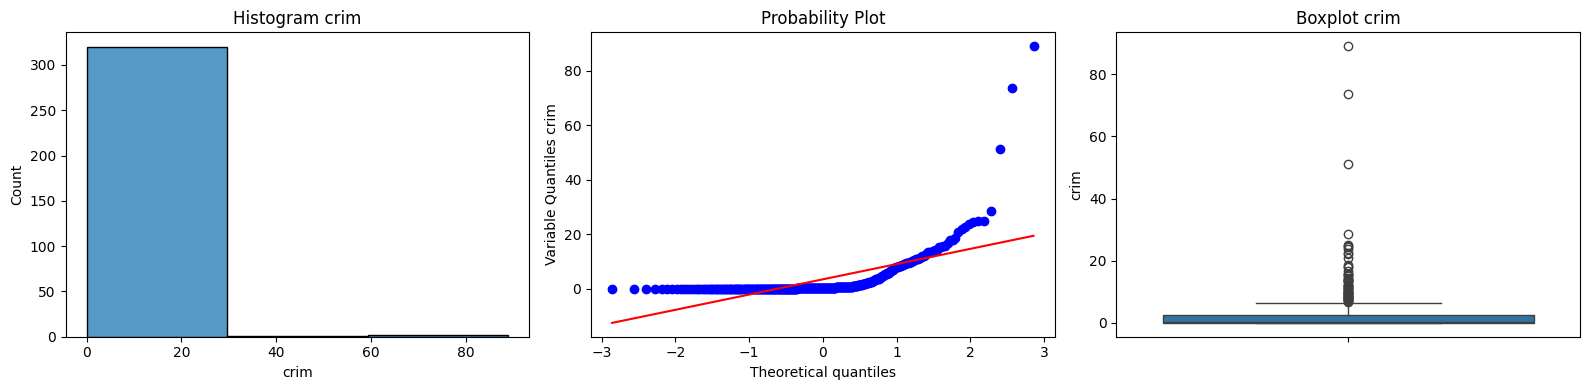

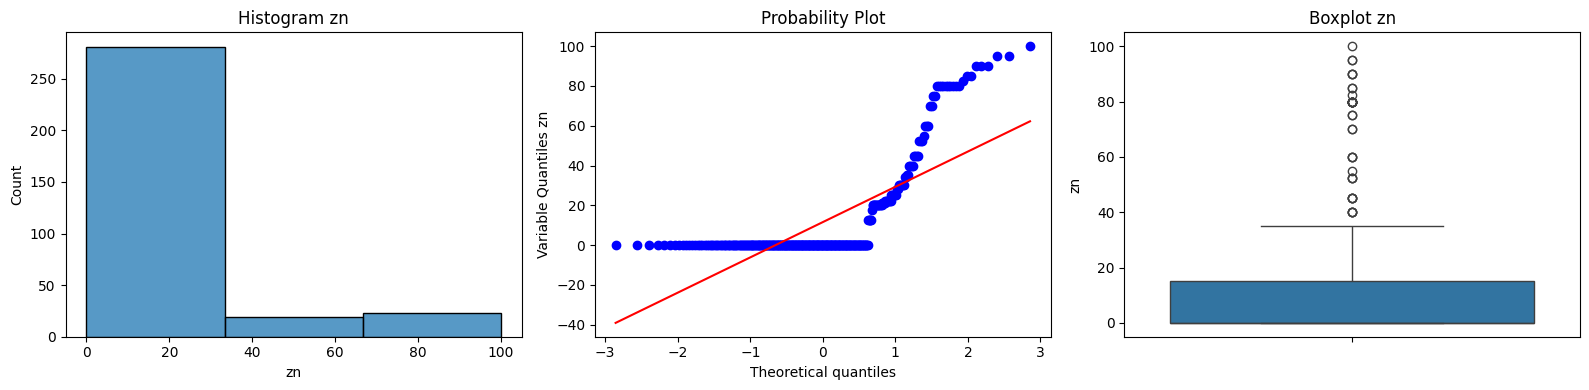

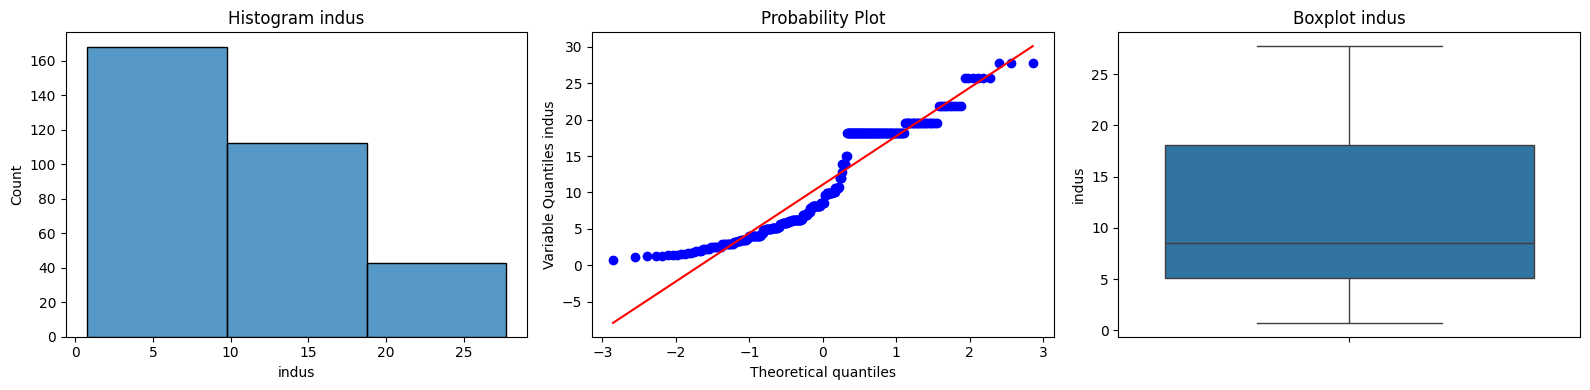

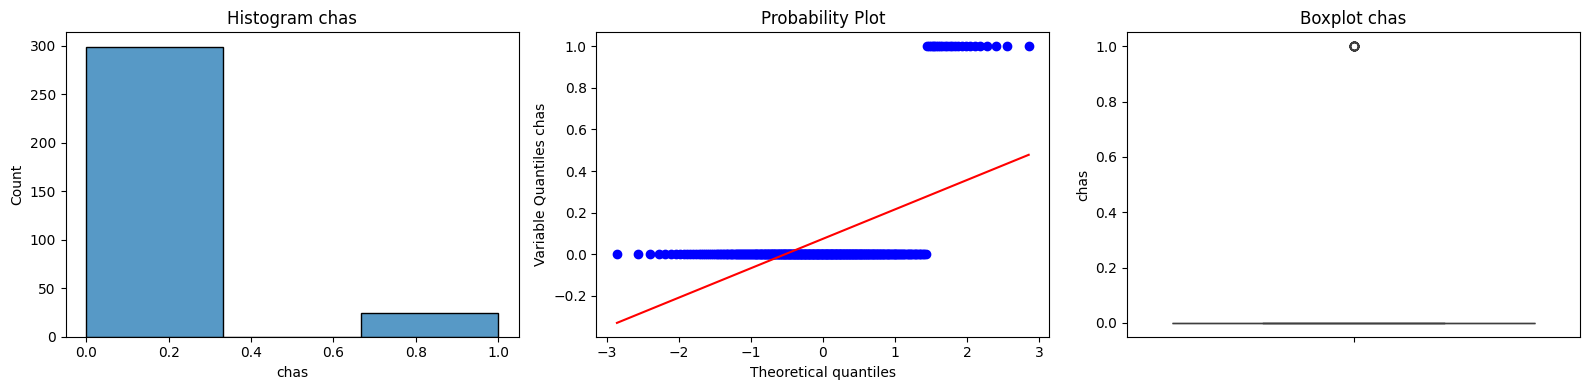

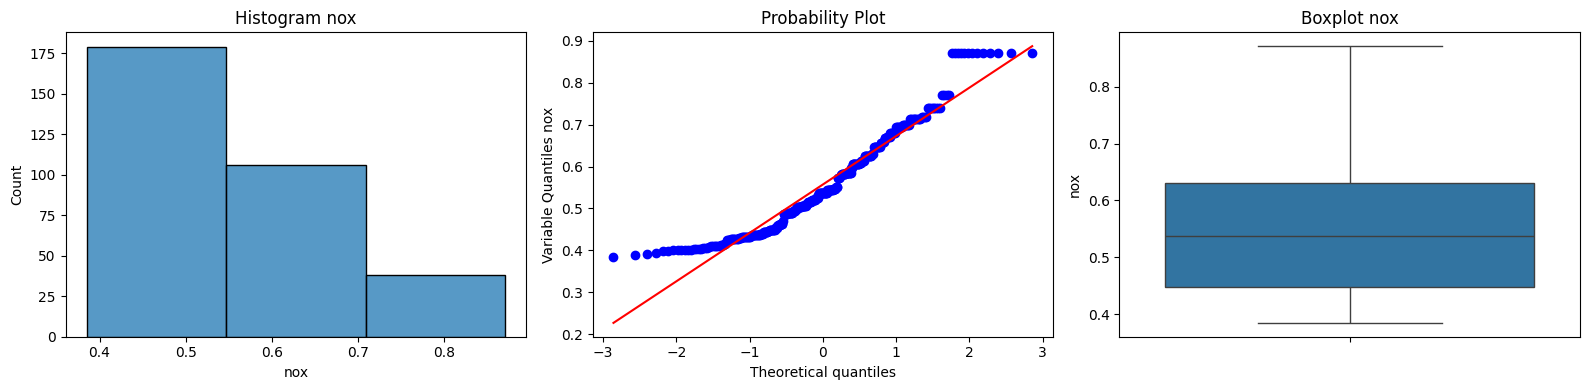

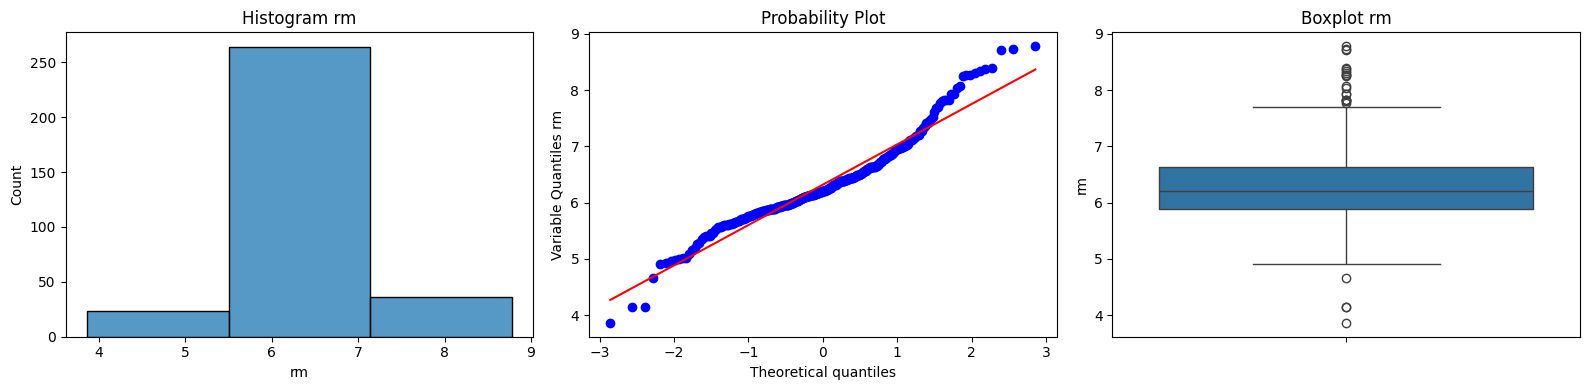

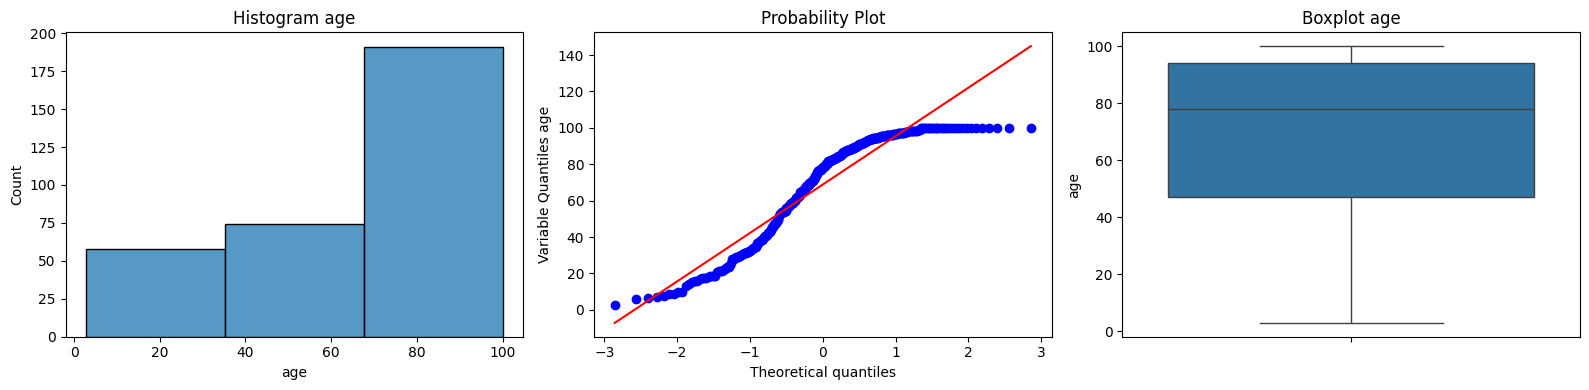

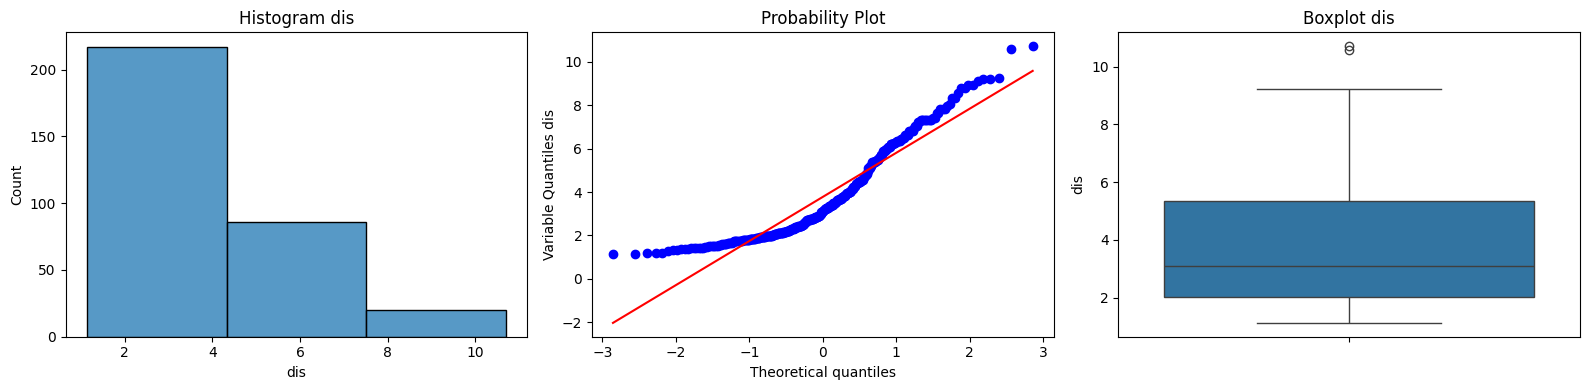

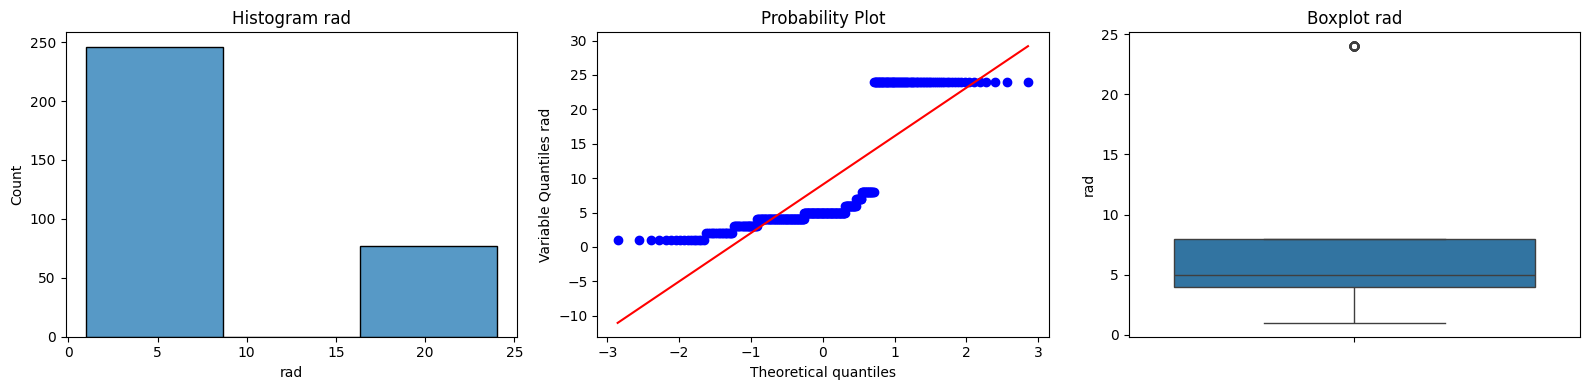

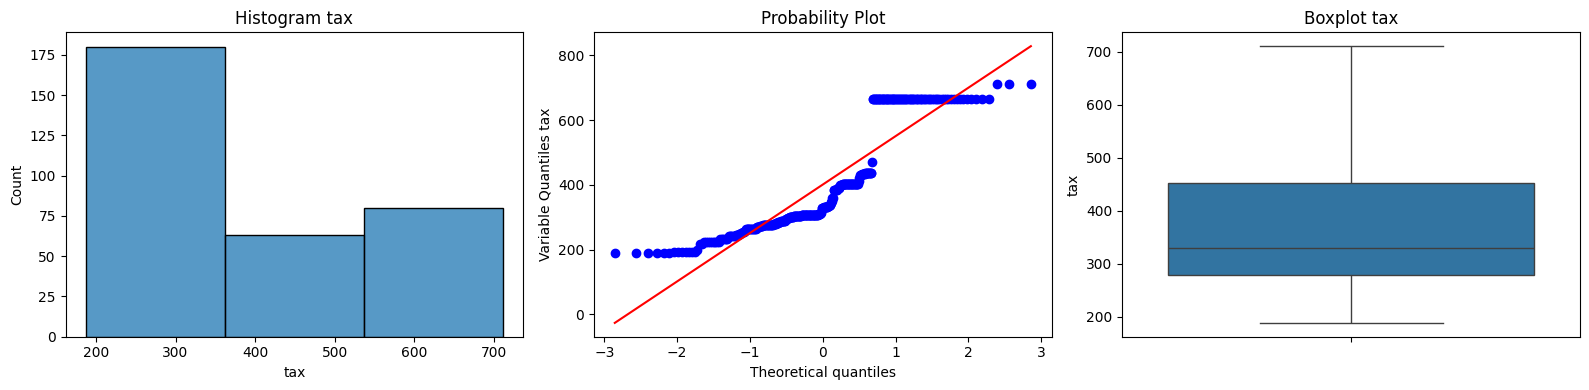

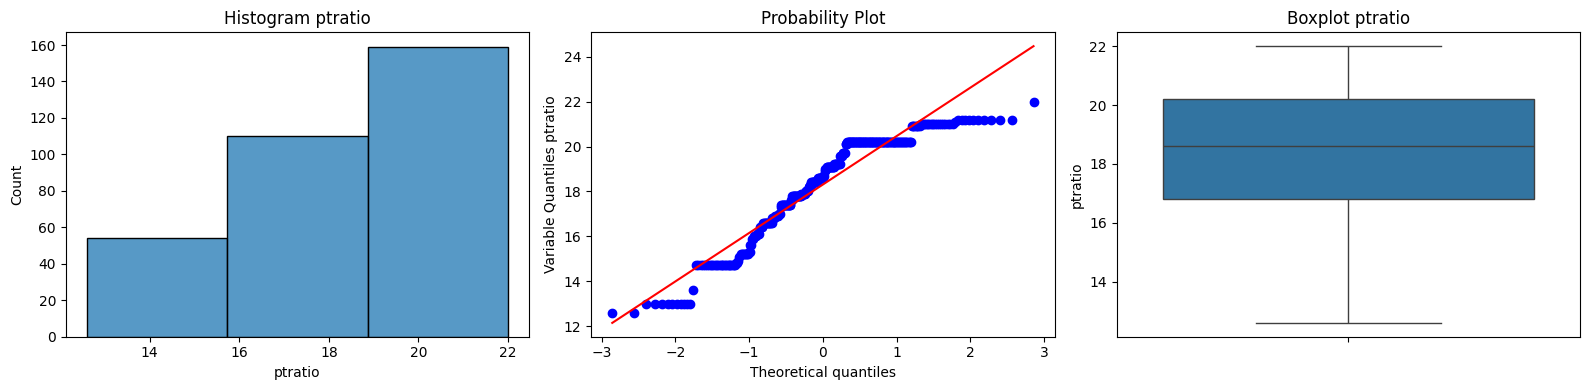

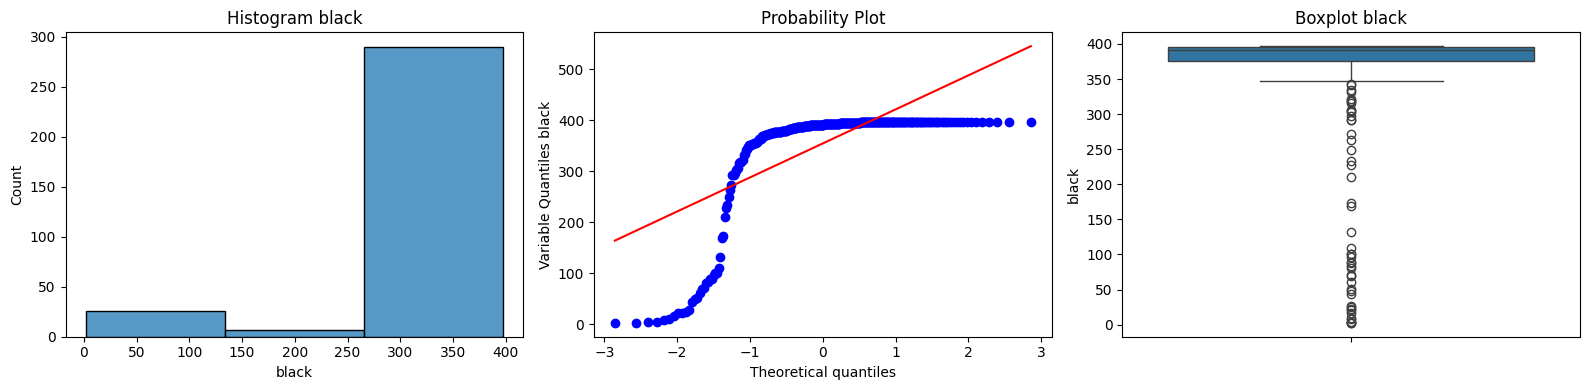

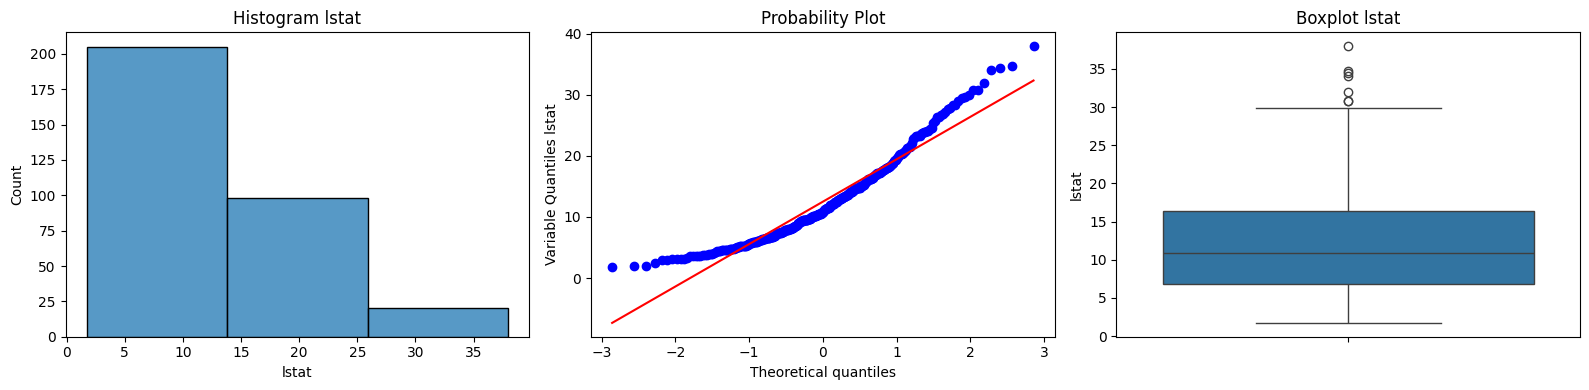

In [ ]:
check_plot(X_train)

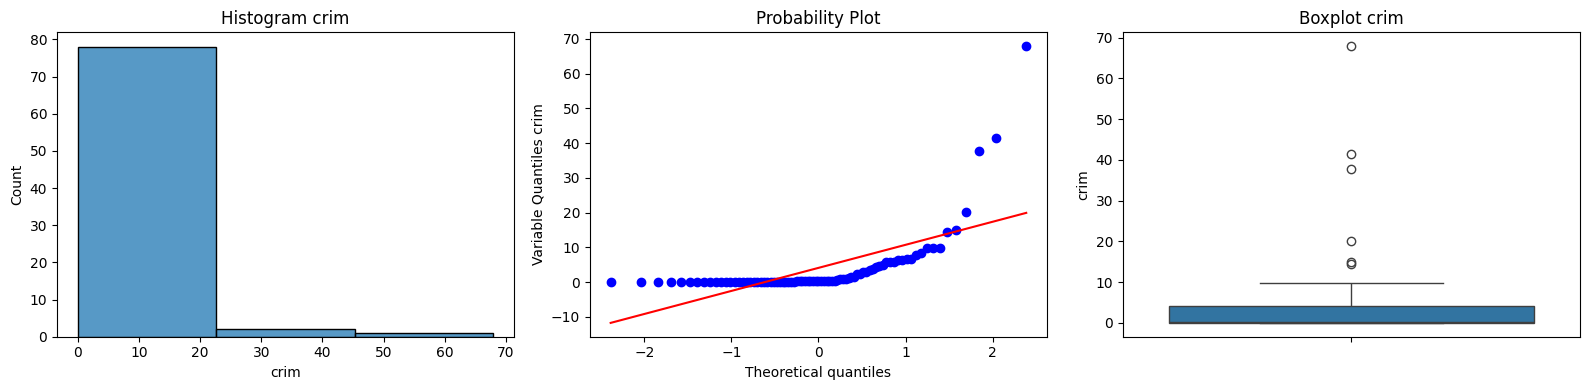

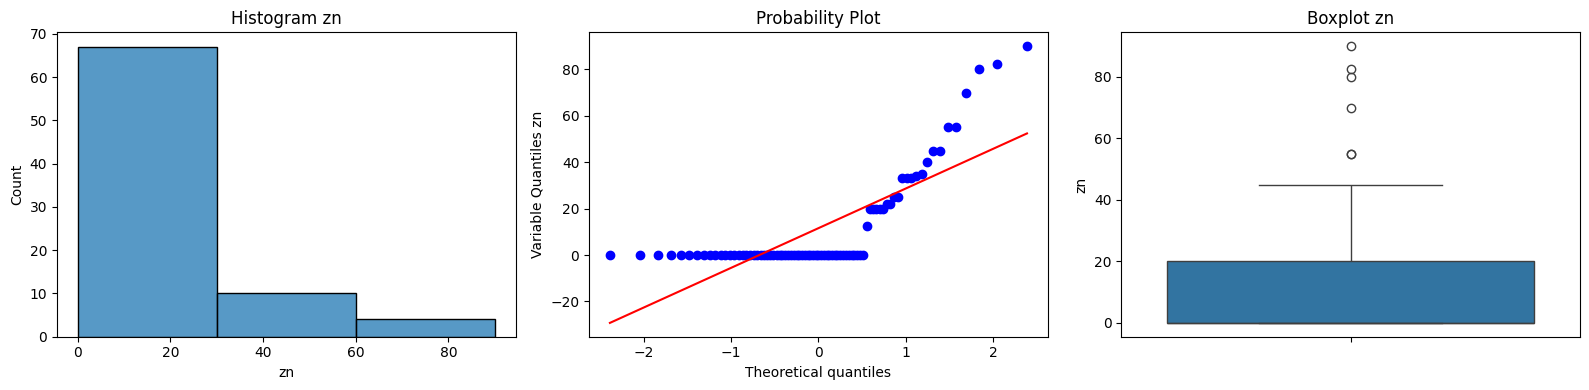

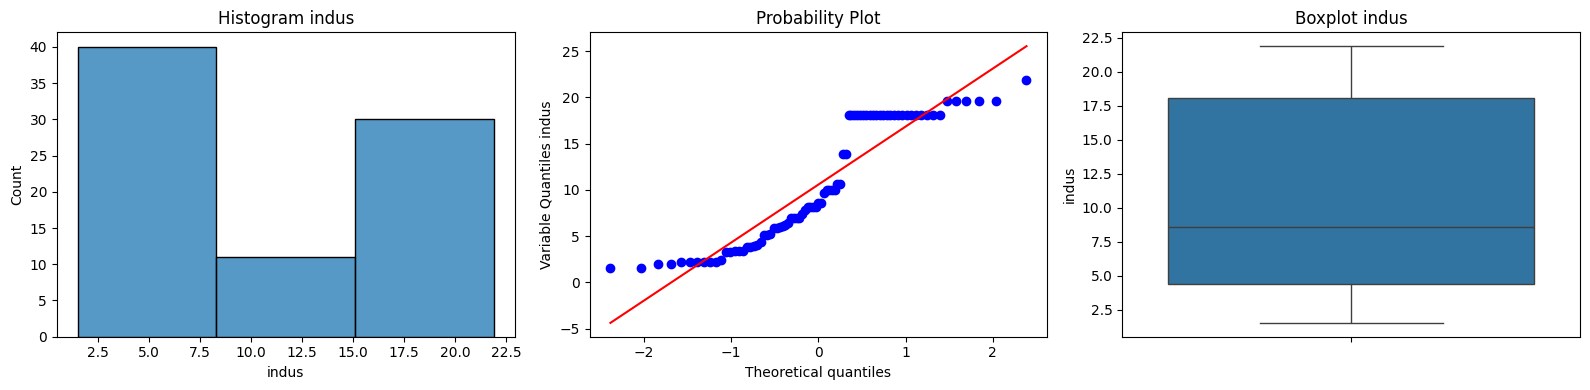

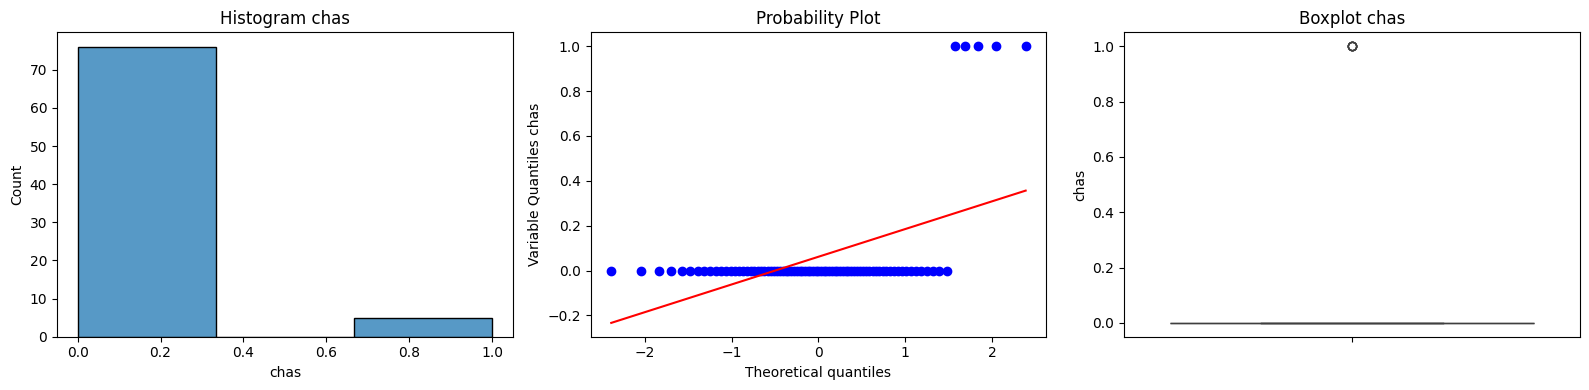

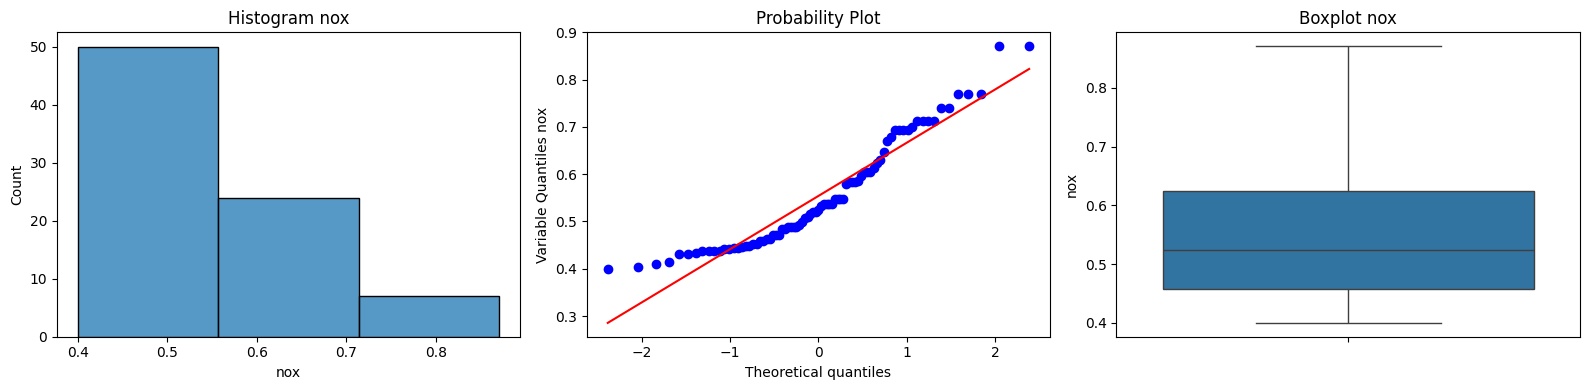

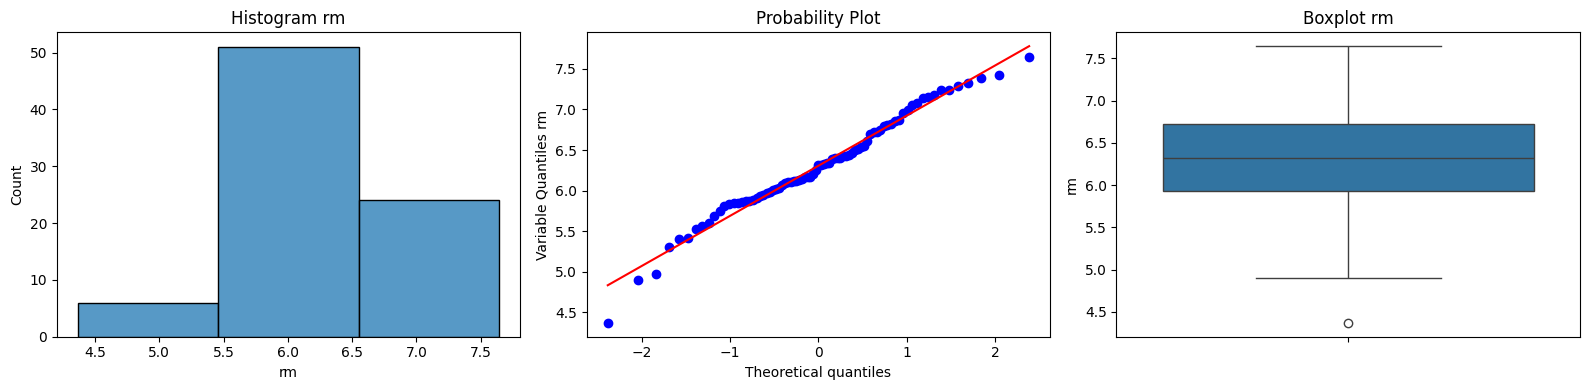

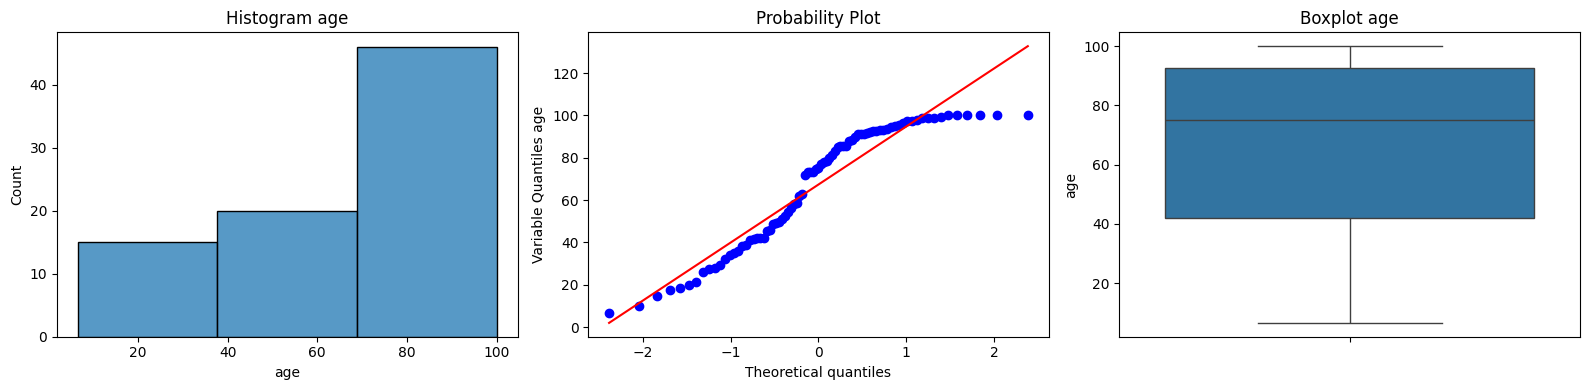

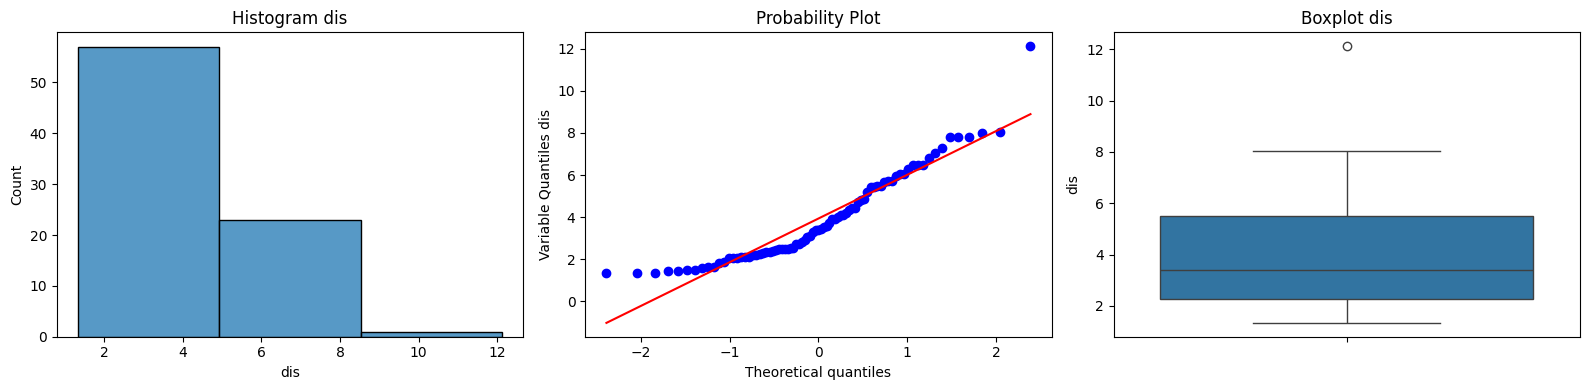

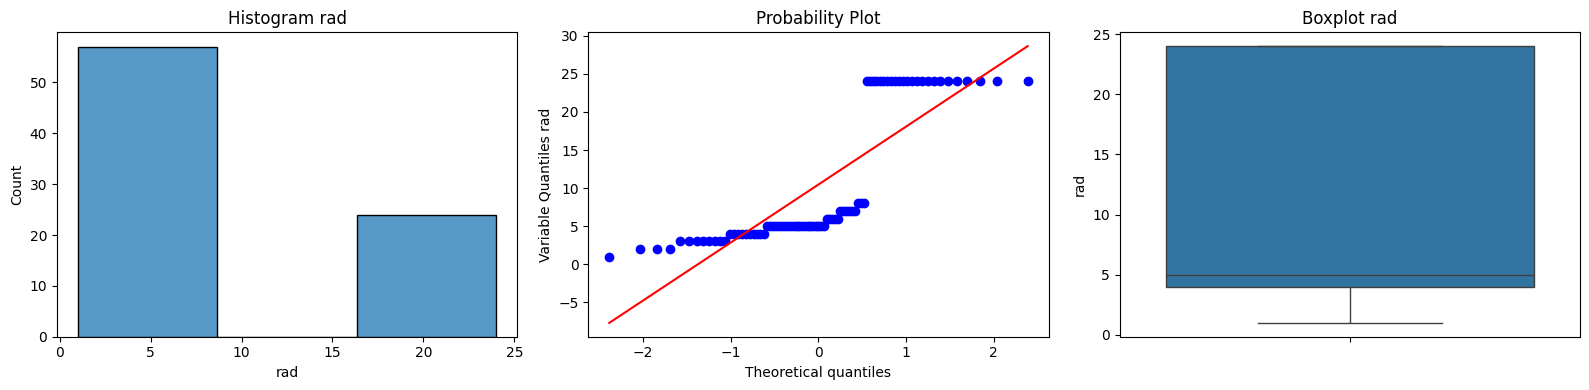

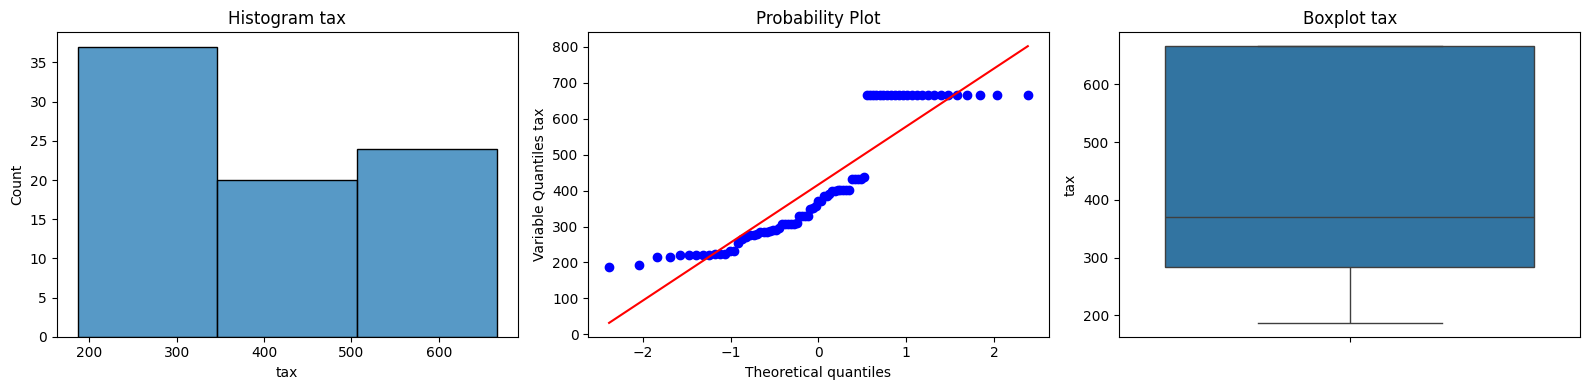

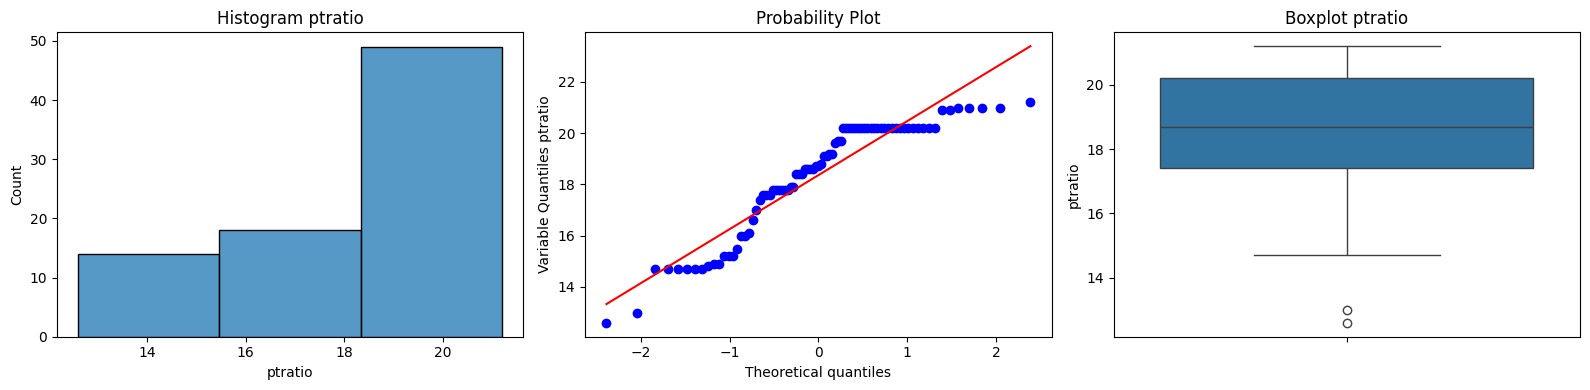

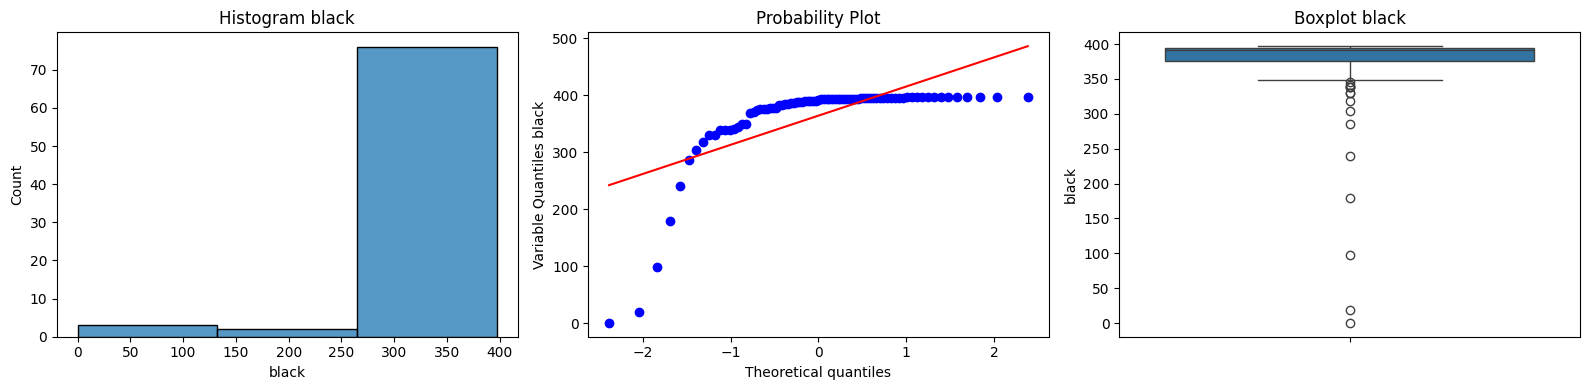

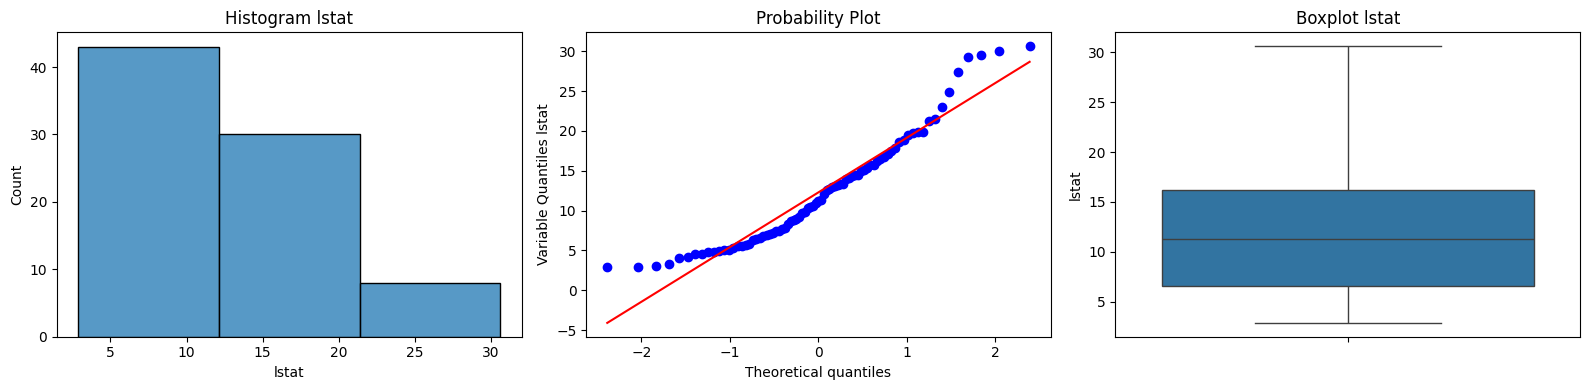

In [ ]:
check_plot(X_val)

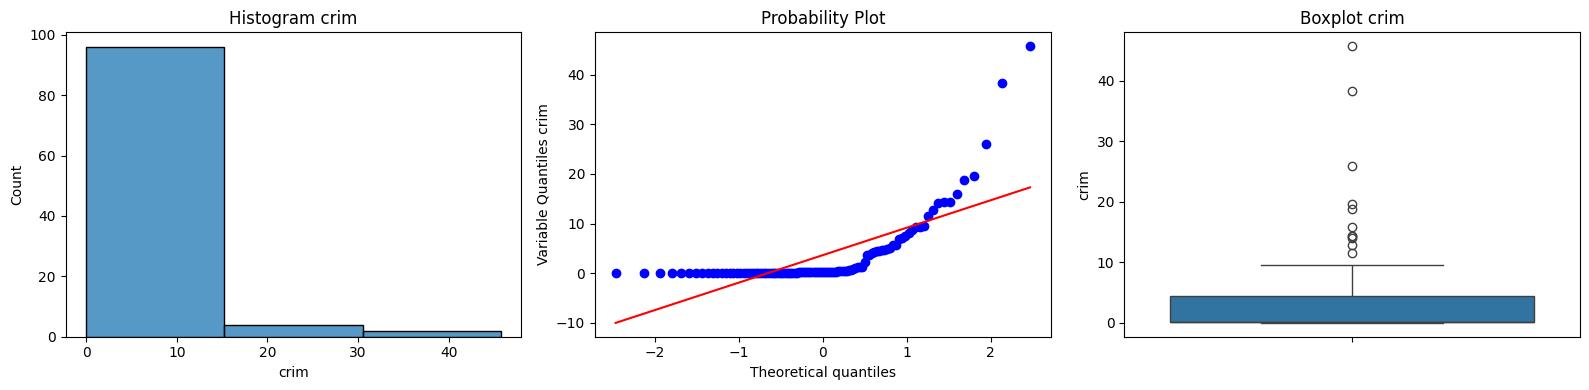

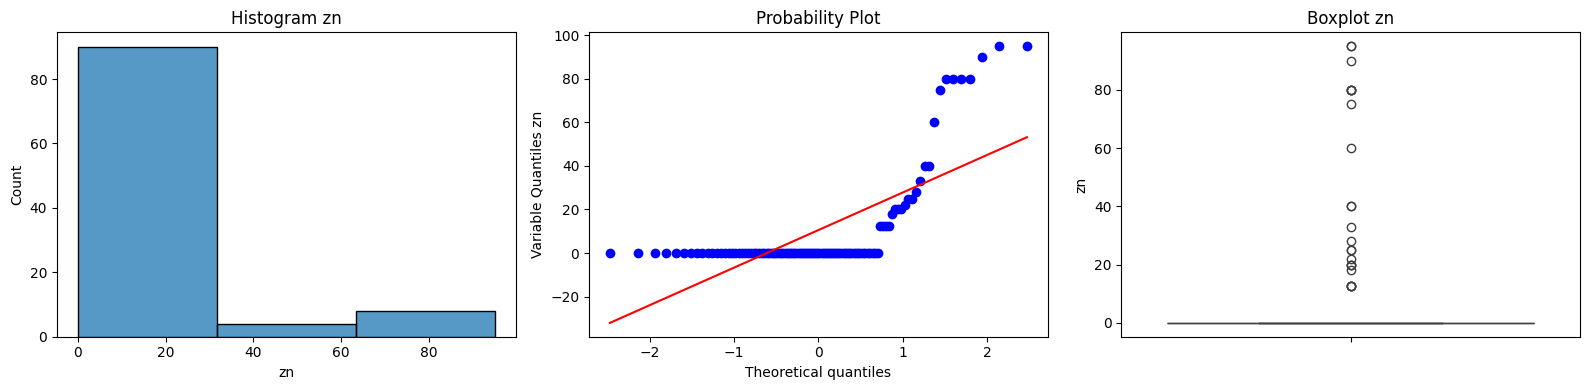

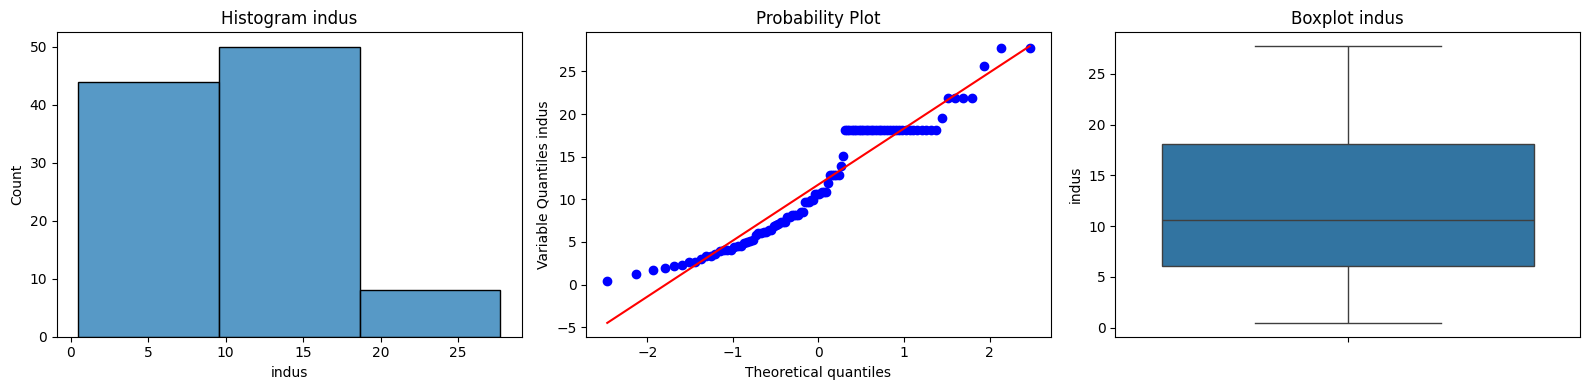

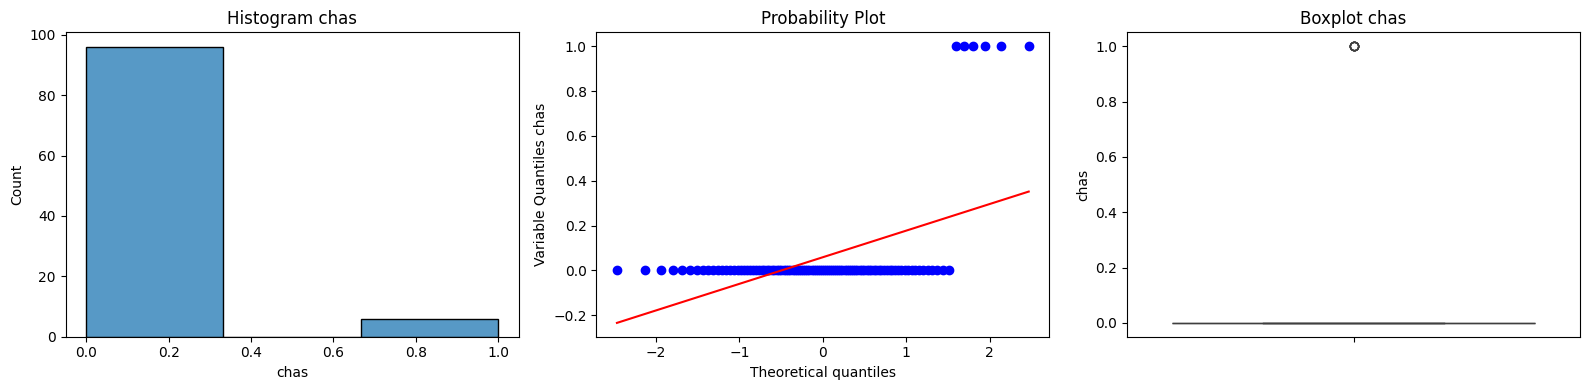

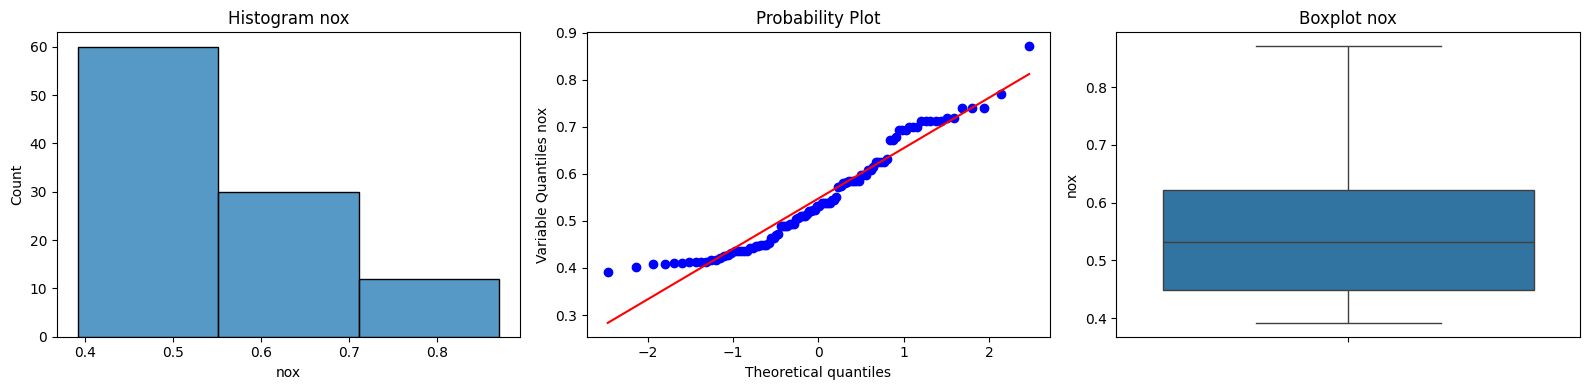

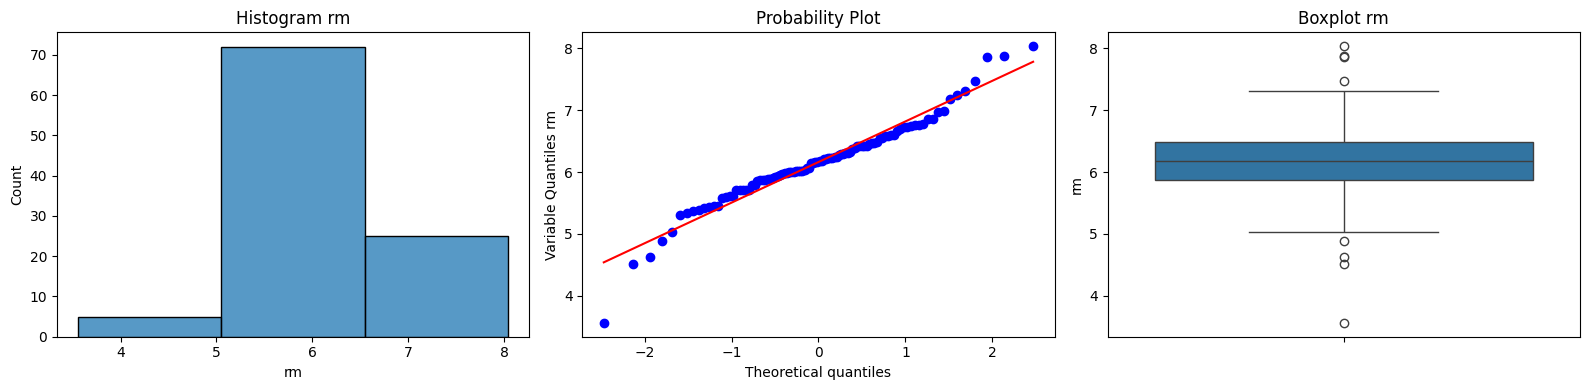

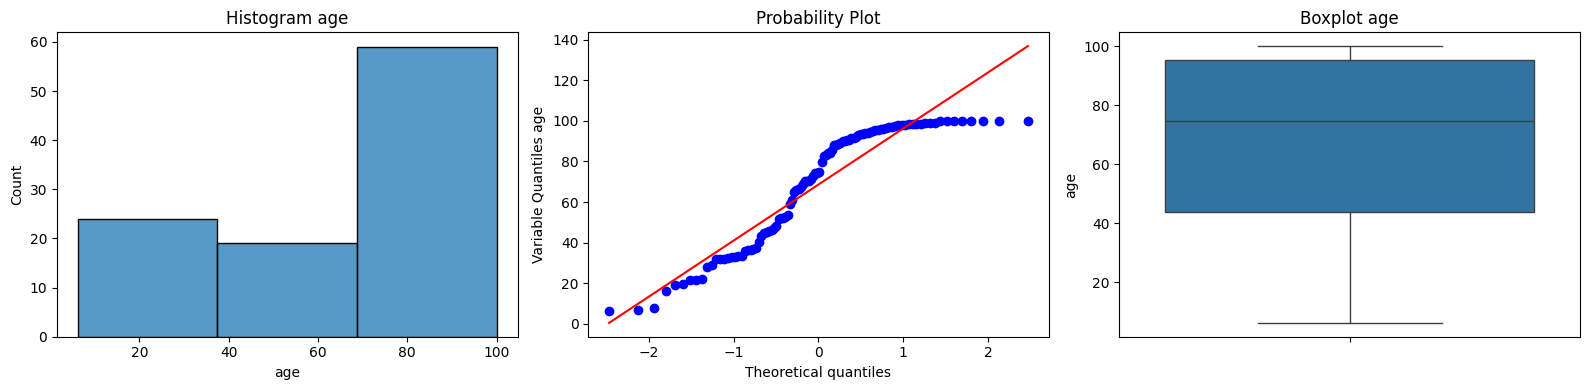

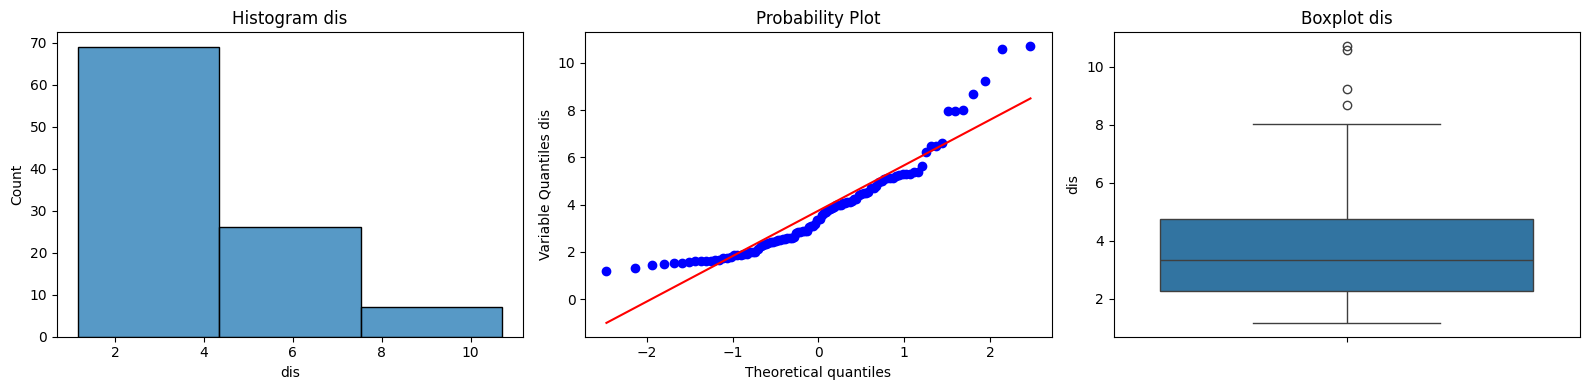

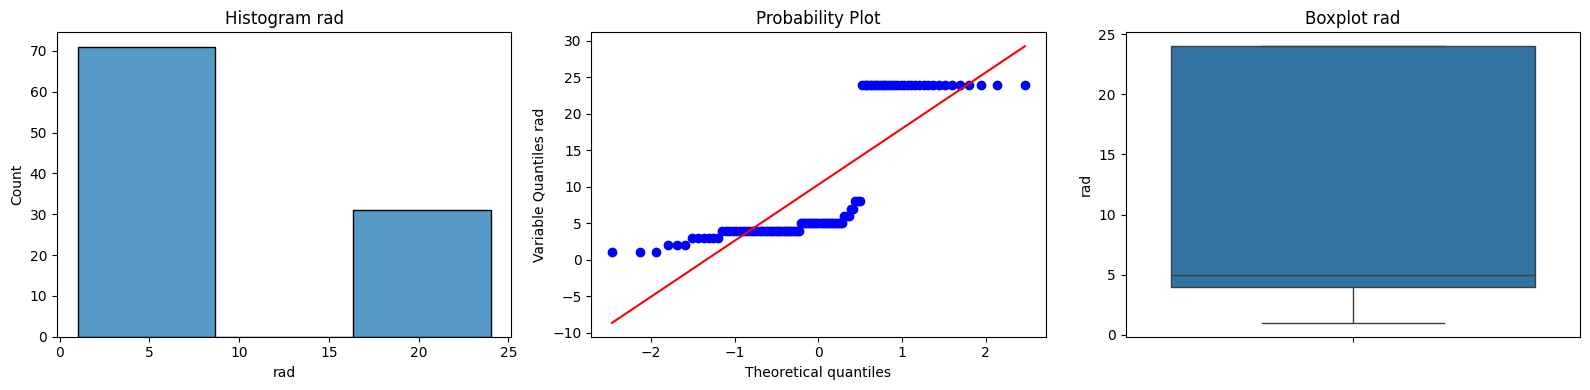

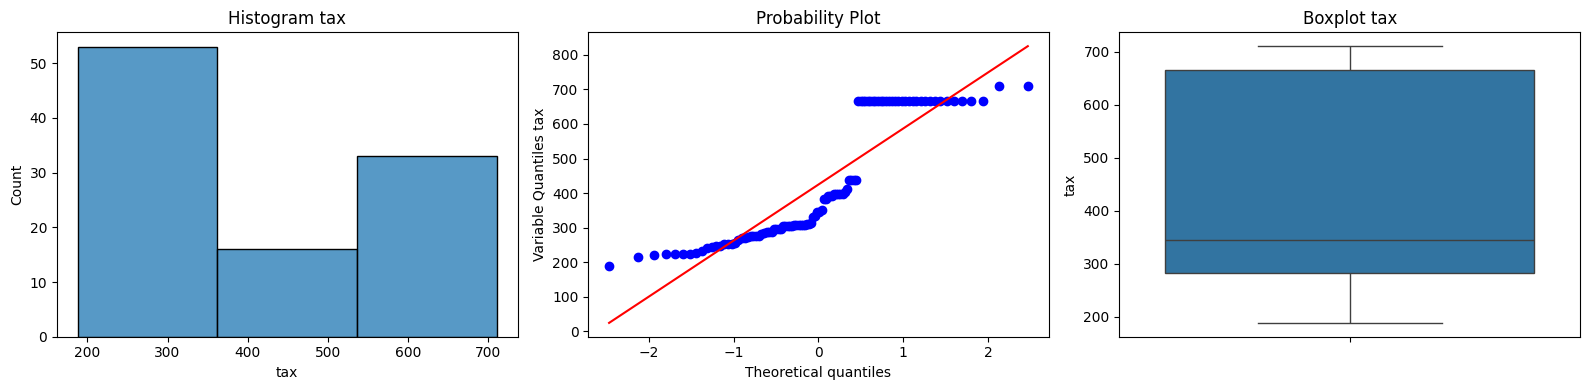

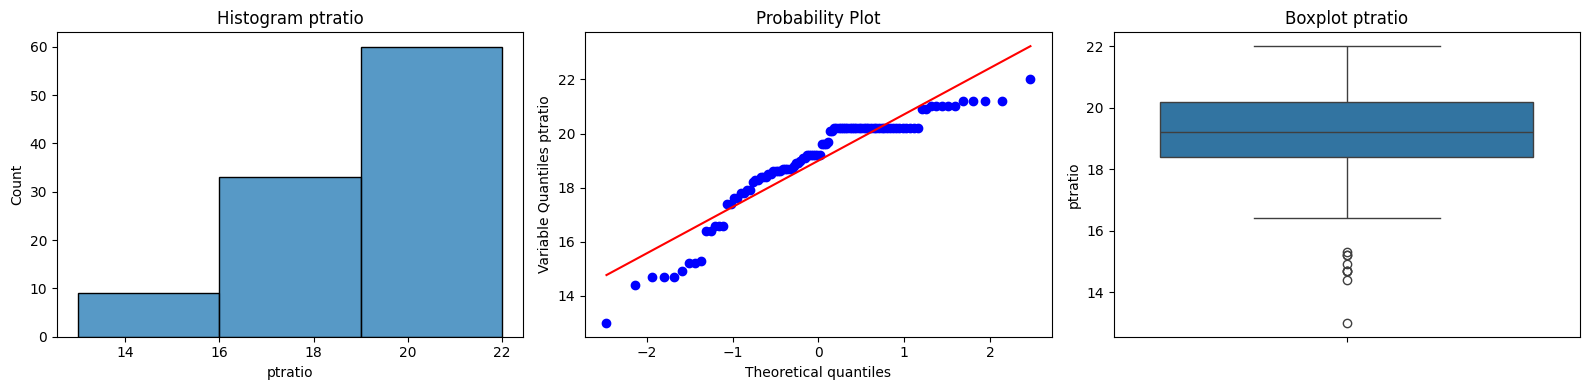

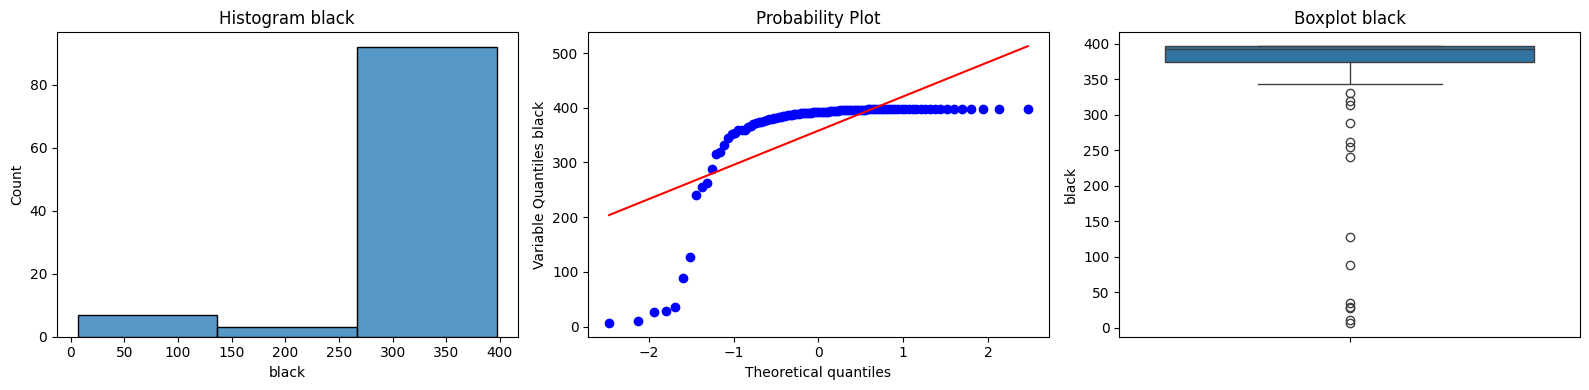

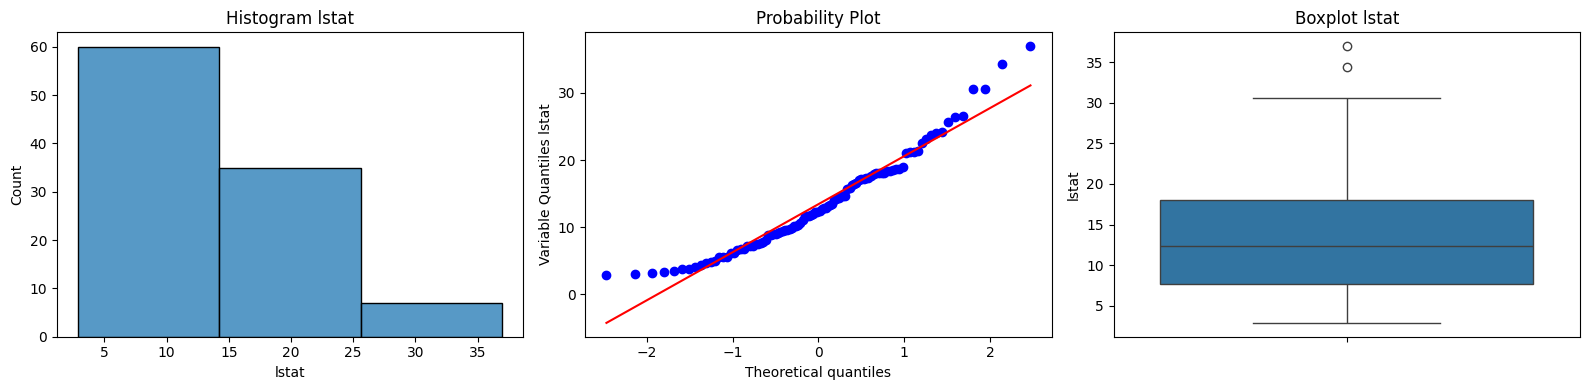

In [ ]:
check_plot(X_test)

# **Insight: 4. Data Cleaning**

1. No missing values found on the all sample dataset.
2. Duplicated values only exist in the sample dataset of output. However, as the duplicated values can't be found on the Features, then we can ignore it as the duplicated values in Output may result from the sama range of the feature values.
3. In this model, we'll ignore the outlier due to the dataset is quite small.

# **5. Correlation Matrix**

As per mentioned in the section **2. Data Exploration**, we do know which Features greatly affected the Target by the Features defintion.

We need check the effect by its statistical value with plot diagram and correlation matrix with Value.

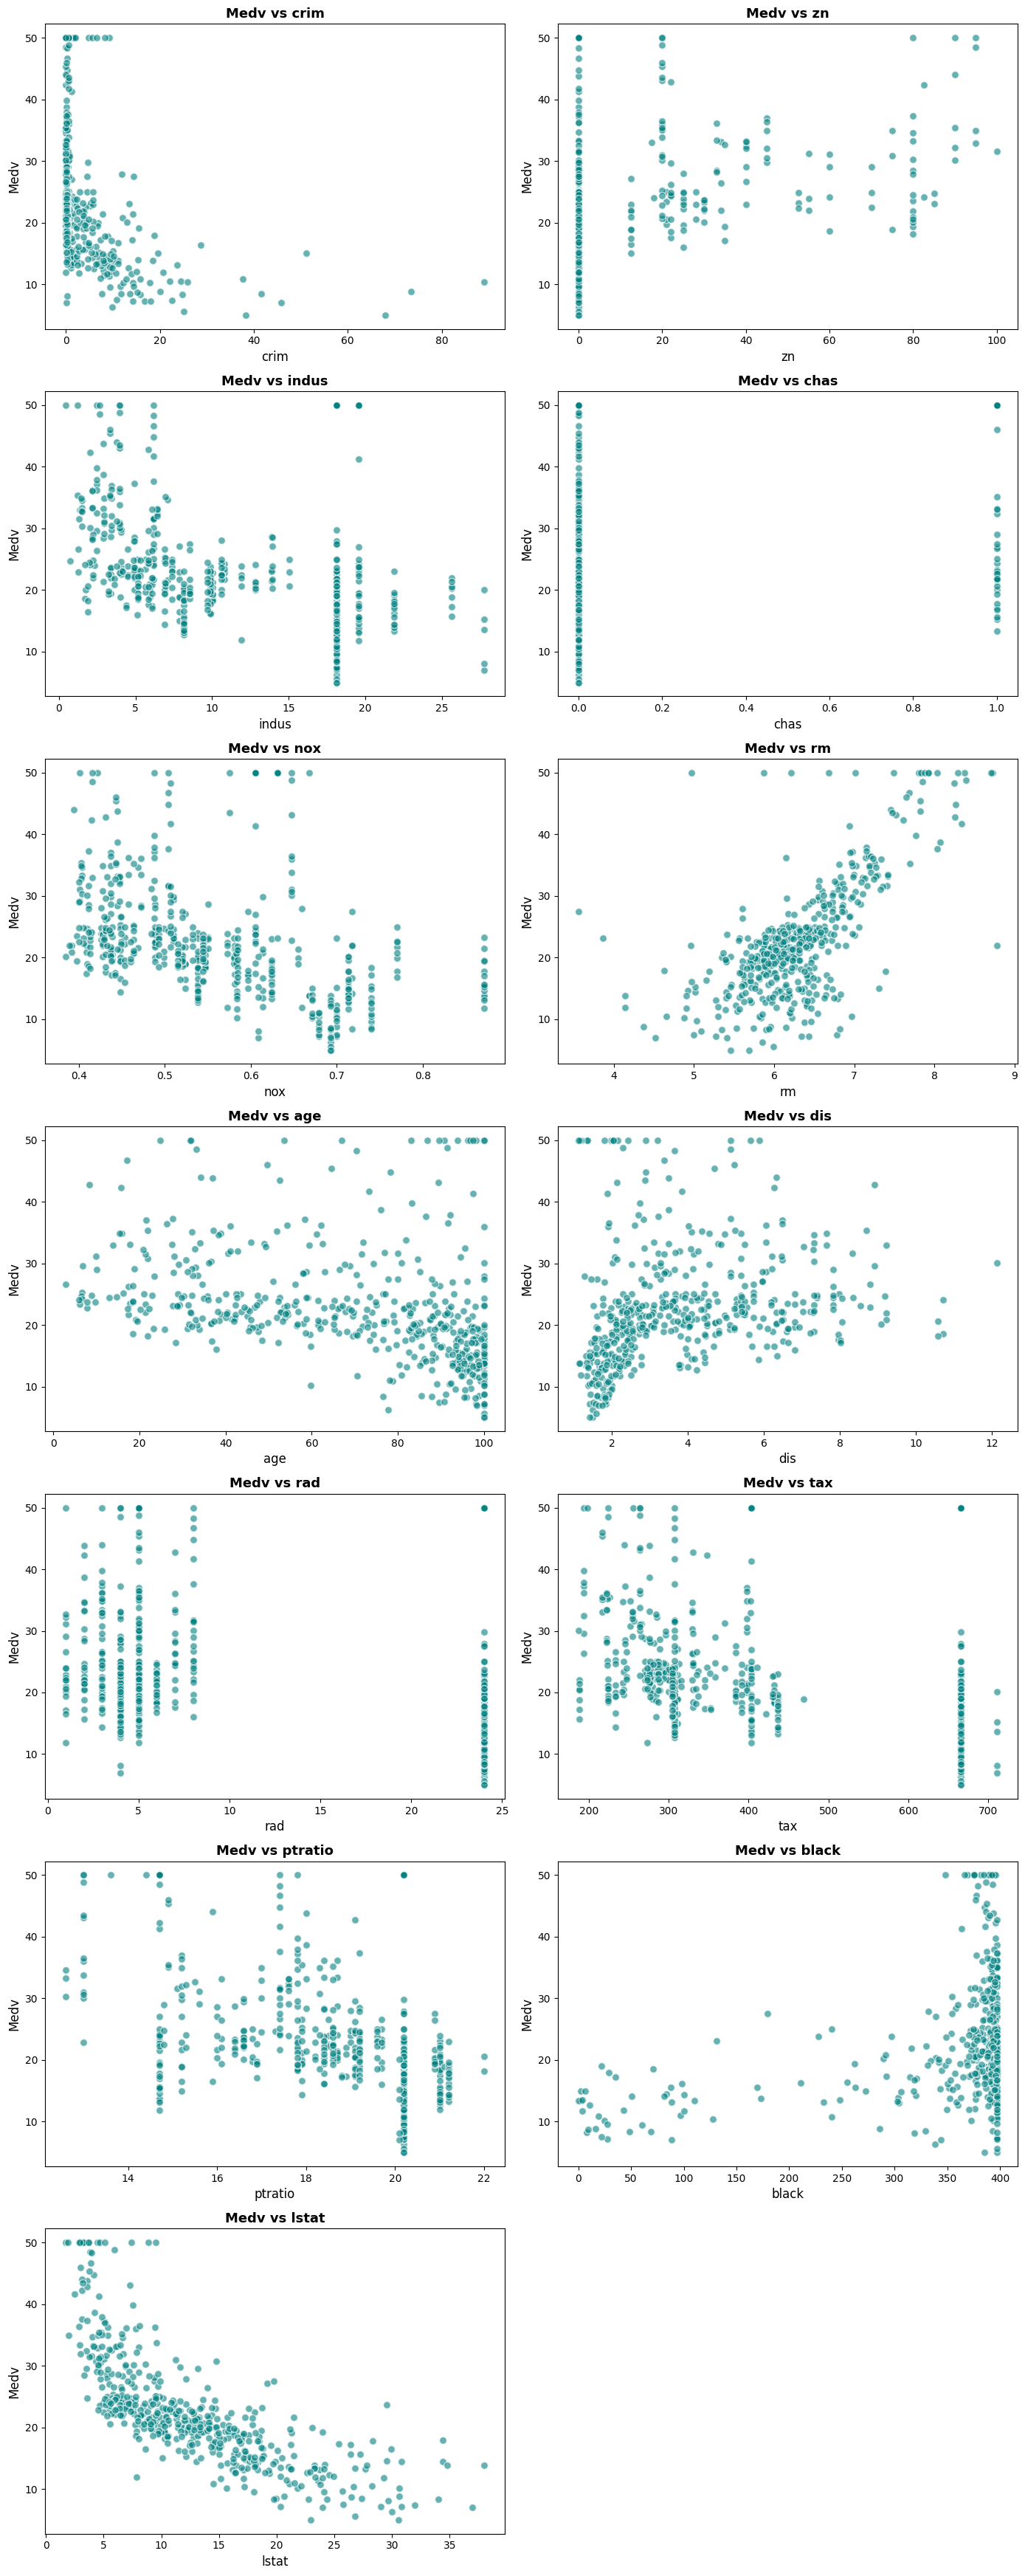

In [ ]:
import matplotlib.pyplot as plt
import math

n_cols = 2
n_rows = math.ceil(len(X.columns) / n_cols)

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(14, 5 * n_rows))

axes = axes.flatten()

color = 'teal'

for i, feature in enumerate(X.columns):

    axes[i].scatter(
        x=X[feature],
        y=df['medv'],
        color=color,
        edgecolor='white',
        s=50,
        alpha=0.6
    )

    axes[i].set_xlabel(feature, fontsize=12)
    axes[i].set_ylabel('Medv', fontsize=12)
    axes[i].set_title(f'Medv vs {feature}', fontsize=13, fontweight='bold')

for j in range(len(X.columns), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [ ]:
correlation_matrix = df.corr(numeric_only=True).round(1)
corr_mat = correlation_matrix['medv'].sort_values(ascending=False)
corr_mat = corr_mat.reset_index()
corr_mat.columns = ['Feature', 'Corr']
corr_mat

,Feature,Corr
0,medv,1.0
1,rm,0.7
2,zn,0.4
3,black,0.3
4,chas,0.2
5,dis,0.2
6,rad,-0.4
7,nox,-0.4
8,crim,-0.4
9,age,-0.4


<Axes: >

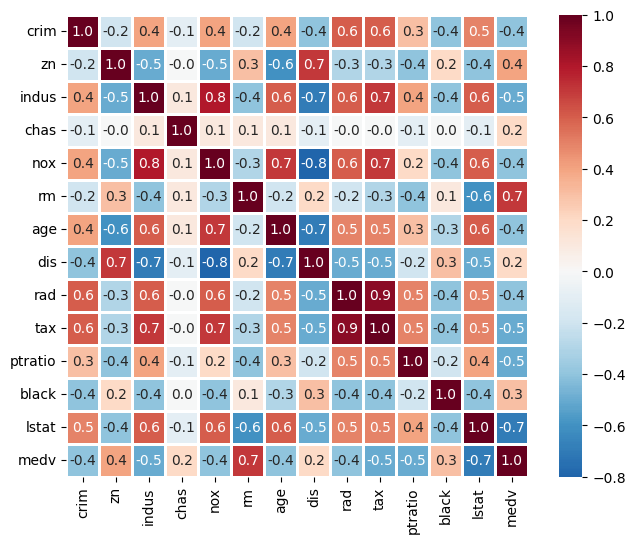

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.1f', linewidths=1, square=True,)

In [ ]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X = df.drop(columns=['medv'])

X_vif = add_constant(X)

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns

vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]

vif_data = vif_data[vif_data["Feature"] != "const"]
vif_data = vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True).round(1)

vif_corr = pd.merge(vif_data, corr_mat, on='Feature', how='left')
vif_corr = vif_corr.sort_values(by="Corr", ascending=False).reset_index(drop=True)
vif_corr['Add to Model'] = vif_corr.apply(
    lambda x: 'Yes' if (1 <= x['VIF'] <= 5) and (abs(x['Corr']) >= 0.5) else 'No',
    axis=1
)

vif_corr


,Feature,VIF,Corr,Add to Model
0,rm,1.9,0.7,Yes
1,zn,2.3,0.4,No
2,black,1.3,0.3,No
3,chas,1.1,0.2,No
4,dis,4.0,0.2,No
5,crim,1.8,-0.4,No
6,age,3.1,-0.4,No
7,rad,7.5,-0.4,No
8,nox,4.4,-0.4,No
9,indus,4.0,-0.5,Yes


# **Insight: 5. Correlation Matrix**

From the correlation matrix, we can see there is an indication of multicollinearity between the features between:

- rad and tax: 0.9 in correlation value.
- ⁠nox and dis, nox and indus, age and dis, nox and age, indus and tax: ~absoulte(0.7) in correlation value.

Multicollinearity will make the model confused and resulting in unstable computing due to its Features simultaneously move with another Features (having its own correlation).

Therefore, we need to compute the Variance Inflation Factor (VIF) to detect the features with no multicollinearity.

**We'll use features that har the coefficient of VIF between  and 5, as it's indicated that the Features has low multicollinearity and with moderate model stability. Those Features will be:**

   **- rm, istat, ptratio, and indus.**

# **6. Train and Evaluating The Model**

In this section, we'll compare the performance, check B coefficient, and find the best alpha of the models, which entails:
1. Regression Model with all of the features.
2. Regression Model with 4 selected features from VIF and Correlation Table.
3. Ridge Regression using Ridge.
4. Lasso Regression using Lasso.
5. Mix of Ridge and Lasso Regression using Elastic Net.


Detailed explanation for each model and what dataset characteristic is the most suitable:

1. Rgression Model (OLS)

It's suitable for dataset that possesses Features with no multicollinearity

2. Ridge Rgression (L2 Penalty)

Suitable for dataset that contains high multicollinearity. Instead of nulling the noise Features, this method will shrinks their coefficient to be near 0.

3. Lasso Regression (L1 Penalty)

Suitable for dataset with high-dimensional data containing a lot of irrelavant features. This method will transform the coefficient for the noise Features to abosulte 0.

4. Elastic Net (L1 + L2 Penalty)

Suitable for dataset with highly correlated features. This method combines both penalties to maintain groups of correlated variables while still applying the necessary shrinkage for stability.

In [ ]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

## **6.1. Regression Model with all of the features.**

In [ ]:
model_lr = LinearRegression()
model_lr.fit(X_train_scaled, y_train)

train_r2_lr = model_lr.score(X_train_scaled, y_train)
val_r2_lr = r2_score(y_val, model_lr.predict(X_val_scaled))
gap_lr = train_r2_lr - val_r2_lr

print('6.1. Regression Model with all of the features')
print('=' * 50)
print(f'  Training R² : {train_r2_lr:.4f}')
print(f'  Val R²      : {val_r2_lr:.4f}')
print(f'  Gap         : {gap_lr:.4f}')
print()
n_kept = (np.abs(model_lr.coef_) > 0.001).sum()
n_removed = 13 - n_kept
print(f'Linear Regression kept {n_kept} features and REMOVED {n_removed} features.')
print()
print('Features Linear Regression kept:')
for feat, coef in zip(X_train, model_lr.coef_):
    if abs(coef) > 0.001:
        marker = '✅' if abs(coef) > 0.01 else '❌'
        print(f'  {marker} {feat:12s}  β = {coef:.4f}')
print()

6.1. Regression Model with all of the features
  Training R² : 0.7643
  Val R²      : 0.6725
  Gap         : 0.0918

Linear Regression kept 13 features and REMOVED 0 features.

Features Linear Regression kept:
  ✅ crim          β = -0.9155
  ✅ zn            β = 0.7721
  ✅ indus         β = 0.3040
  ✅ chas          β = 0.7888
  ✅ nox           β = -2.2409
  ✅ rm            β = 3.6258
  ✅ age           β = -0.0701
  ✅ dis           β = -3.2155
  ✅ rad           β = 1.8673
  ✅ tax           β = -1.4402
  ✅ ptratio       β = -2.0920
  ✅ black         β = 1.2062
  ✅ lstat         β = -3.2996



## **6.2. Regression Model with 4 selected features from VIF and Correlation Table.**

In [ ]:
X_train_scaled1 = scaler.fit_transform(X_train[['rm', 'lstat', 'ptratio', 'indus']])
X_val_scaled1 = scaler.transform(X_val[['rm', 'lstat', 'ptratio', 'indus']])
X_test_scaled1 = scaler.transform(X_test[['rm', 'lstat', 'ptratio', 'indus']])


model_lr4 = LinearRegression()
model_lr4.fit(X_train_scaled1, y_train)

train_r2_lr4 = model_lr4.score(X_train_scaled1, y_train)
val_r2_lr4 = r2_score(y_val, model_lr4.predict(X_val_scaled1))
gap_lr4 = train_r2_lr4 - val_r2_lr4

print('6.2. Regression Model with 4 selected features from VIF and Correlation Table')
print('=' * 78)
print(f'  Training R² : {train_r2_lr4:.4f}')
print(f'  Val R²      : {val_r2_lr4:.4f}')
print(f'  Gap         : {gap_lr4:.4f}')

print()
n_kept = (np.abs(model_lr4.coef_) > 0.001).sum()
n_removed = 13 - n_kept
print(f'Linear Regression kept {n_kept} features and REMOVED {n_removed} features.')
print()
print('Features Linear Regression kept:')
for feat, coef in zip(X_train, model_lr4.coef_):
    if abs(coef) > 0.001:
        marker = '✅' if abs(coef) > 0.01 else '❌'
        print(f'  {marker} {feat:12s}  β = {coef:.4f}')
print()

6.2. Regression Model with 4 selected features from VIF and Correlation Table
  Training R² : 0.7000
  Val R²      : 0.6127
  Gap         : 0.0873

Linear Regression kept 4 features and REMOVED 9 features.

Features Linear Regression kept:
  ✅ crim          β = 3.9479
  ✅ zn            β = -4.0138
  ✅ indus         β = -2.0306
  ✅ chas          β = 0.3498



## **6.3. Ridge Regression using RidgeCV.**

In [ ]:
alpha_space = np.logspace(-3, 2, 6)
evaluation_log = []

print("Log Iterasi Ridge Regression (Train vs Validation)")
print('=' * 52)
for alpha_val in alpha_space:
    ridge_model = Ridge(alpha=alpha_val)

    ridge_model.fit(X_train_scaled, y_train)

    y_train_pred = ridge_model.predict(X_train_scaled)
    y_val_pred = ridge_model.predict(X_val_scaled)

    r2_train = r2_score(y_train, y_train_pred)
    r2_val = r2_score(y_val, y_val_pred)

    r2_gap = r2_train - r2_val

    print(f"Lambda: {alpha_val:10.4f} | R2 Train: {r2_train:.4f} | R2 Val: {r2_val:.4f} | Gap: {r2_gap:.4f}")

    evaluation_log.append({
        'alpha': alpha_val,
        'r2_train': r2_train,
        'r2_val': r2_val,
        'gap': r2_gap
    })

log_df = pd.DataFrame(evaluation_log)

best_config = log_df.loc[log_df['r2_val'].idxmax()]

print(f"\n>> Lambda Optimal Empiris: {best_config['alpha']:.4f}")
print(f">> Matriks Performa Optimal -> R2 Train: {best_config['r2_train']:.4f} | R2 Val: {best_config['r2_val']:.4f} | Gap: {best_config['gap']:.4f}")


Log Iterasi Ridge Regression (Train vs Validation)
Lambda:     0.0010 | R2 Train: 0.7643 | R2 Val: 0.6725 | Gap: 0.0918
Lambda:     0.0100 | R2 Train: 0.7643 | R2 Val: 0.6725 | Gap: 0.0918
Lambda:     0.1000 | R2 Train: 0.7643 | R2 Val: 0.6725 | Gap: 0.0918
Lambda:     1.0000 | R2 Train: 0.7643 | R2 Val: 0.6726 | Gap: 0.0917
Lambda:    10.0000 | R2 Train: 0.7630 | R2 Val: 0.6731 | Gap: 0.0899
Lambda:   100.0000 | R2 Train: 0.7344 | R2 Val: 0.6644 | Gap: 0.0700

>> Lambda Optimal Empiris: 10.0000
>> Matriks Performa Optimal -> R2 Train: 0.7630 | R2 Val: 0.6731 | Gap: 0.0899


The best Alpha for Rigde model is 10, because the gap R2 score is 0.0899

In [ ]:
model_lr = LinearRegression()
model_lr.fit(X_train_scaled, y_train)

train_r2_lr = model_lr.score(X_train_scaled, y_train)
val_r2_lr = r2_score(y_val, model_lr.predict(X_val_scaled))
gap_lr = train_r2_lr - val_r2_lr


model_ridge = Ridge(alpha=10.0)
model_ridge.fit(X_train_scaled, y_train)

train_r2_ridge = model_ridge.score(X_train_scaled, y_train)
val_r2_ridge = r2_score(y_val, model_ridge.predict(X_val_scaled))
gap_ridge = train_r2_ridge - val_r2_ridge

print('6.3. Ridge Regression using Ridge - alpha 10.0')
print('=' * 55)
print(f'  Training R² : {train_r2_ridge:.4f}')
print(f'  Val R²      : {val_r2_ridge:.4f}')
print(f'  Gap         : {gap_ridge:.4f}')
print()
if val_r2_ridge > val_r2_lr:
    print(f'✅ Lasso IMPROVED test R² by {val_r2_ridge - val_r2_lr:.4f}!')
print()

n_kept = (np.abs(model_ridge.coef_) > 0.001).sum()
n_removed = 13 - n_kept
print(f'Ridge kept {n_kept} features and REMOVED {n_removed} features')
print()
print('Features Lasso kept:')
for feat, coef in zip(X_train, model_ridge.coef_):
    if abs(coef) > 0.001:
        marker = '✅' if abs(coef) > 0.01 else '❌'
        print(f'  {marker} {feat:12s}  β = {coef:.4f}')
print()

6.3. Ridge Regression using Ridge - alpha 10.0
  Training R² : 0.7630
  Val R²      : 0.6731
  Gap         : 0.0899

✅ Lasso IMPROVED test R² by 0.0007!

Ridge kept 13 features and REMOVED 0 features

Features Lasso kept:
  ✅ crim          β = -0.8196
  ✅ zn            β = 0.6075
  ✅ indus         β = 0.0995
  ✅ chas          β = 0.8071
  ✅ nox           β = -1.8770
  ✅ rm            β = 3.6314
  ✅ age           β = -0.0694
  ✅ dis           β = -2.8077
  ✅ rad           β = 1.3112
  ✅ tax           β = -0.9962
  ✅ ptratio       β = -1.9907
  ✅ black         β = 1.1787
  ✅ lstat         β = -3.2083



## **6.4. Lasso Regression using Lasso.**

In [ ]:
alpha_space = np.logspace(-4, 1, 50)
evaluation_log = []

print("Log Iterasi Lasso Regression (Train vs Validation)")
print('=' * 52)
for alpha_val in alpha_space:
    Lasso_model = Lasso(alpha=alpha_val, max_iter=10000, random_state=42)

    Lasso_model.fit(X_train_scaled, y_train)

    y_train_pred = Lasso_model.predict(X_train_scaled)
    y_val_pred = Lasso_model.predict(X_val_scaled)

    r2_train = r2_score(y_train, y_train_pred)
    r2_val = r2_score(y_val, y_val_pred)

    r2_gap = r2_train - r2_val

    print(f"Lambda: {alpha_val:10.4f} | R2 Train: {r2_train:.4f} | R2 Val: {r2_val:.4f} | Gap: {r2_gap:.4f}")

    evaluation_log.append({
        'alpha': alpha_val,
        'r2_train': r2_train,
        'r2_val': r2_val,
        'gap': r2_gap
    })

log_df = pd.DataFrame(evaluation_log)

best_config = log_df.loc[log_df['r2_val'].idxmax()]

print(f"\n>> Lambda Optimal Empiris: {best_config['alpha']:.4f}")
print(f">> Matriks Performa Optimal -> R2 Train: {best_config['r2_train']:.4f} | R2 Val: {best_config['r2_val']:.4f} | Gap: {best_config['gap']:.4f}")


Log Iterasi Lasso Regression (Train vs Validation)
Lambda:     0.0001 | R2 Train: 0.7643 | R2 Val: 0.6725 | Gap: 0.0918
Lambda:     0.0001 | R2 Train: 0.7643 | R2 Val: 0.6725 | Gap: 0.0918
Lambda:     0.0002 | R2 Train: 0.7643 | R2 Val: 0.6725 | Gap: 0.0918
Lambda:     0.0002 | R2 Train: 0.7643 | R2 Val: 0.6725 | Gap: 0.0918
Lambda:     0.0003 | R2 Train: 0.7643 | R2 Val: 0.6725 | Gap: 0.0918
Lambda:     0.0003 | R2 Train: 0.7643 | R2 Val: 0.6725 | Gap: 0.0918
Lambda:     0.0004 | R2 Train: 0.7643 | R2 Val: 0.6725 | Gap: 0.0918
Lambda:     0.0005 | R2 Train: 0.7643 | R2 Val: 0.6725 | Gap: 0.0918
Lambda:     0.0007 | R2 Train: 0.7643 | R2 Val: 0.6725 | Gap: 0.0918
Lambda:     0.0008 | R2 Train: 0.7643 | R2 Val: 0.6725 | Gap: 0.0918
Lambda:     0.0010 | R2 Train: 0.7643 | R2 Val: 0.6724 | Gap: 0.0919
Lambda:     0.0013 | R2 Train: 0.7643 | R2 Val: 0.6724 | Gap: 0.0919
Lambda:     0.0017 | R2 Train: 0.7643 | R2 Val: 0.6724 | Gap: 0.0919
Lambda:     0.0021 | R2 Train: 0.7643 | R2 Val: 0.67

In [ ]:
# Lasso Regression
model_lasso = Lasso(alpha=0.0001)
model_lasso.fit(X_train_scaled, y_train)

train_r2_lasso = model_lasso.score(X_train_scaled, y_train)
val_r2_lasso = r2_score(y_val, model_lasso.predict(X_val_scaled))
gap_lasso = train_r2_lasso - val_r2_lasso

print('6.4. Lasso Regression using Lasso.')
print('=' * 55)
print(f'  Training R² : {train_r2_lasso:.4f}')
print(f'  Val R²      : {val_r2_lasso:.4f}')
print(f'  Gap         : {gap_lasso:.4f}')
print()
if val_r2_lasso > val_r2_lr:
    print(f'✅ Lasso IMPROVED test R² by {val_r2_lasso - val_r2_lr:.4f}!')
print()

n_kept = (np.abs(model_lasso.coef_) > 0.001).sum()
n_removed = 13 - n_kept
print(f'Lasso kept {n_kept} features and REMOVED {n_removed} features')
print()
print('Features Lasso kept:')
for feat, coef in zip(X_train, model_lasso.coef_):
    if abs(coef) > 0.001:
        marker = '✅' if abs(coef) > 0.01 else '❌'
        print(f'  {marker} {feat:12s}  β = {coef:.4f}')
print()

6.4. Lasso Regression using Lasso.
  Training R² : 0.7643
  Val R²      : 0.6725
  Gap         : 0.0918


Lasso kept 13 features and REMOVED 0 features

Features Lasso kept:
  ✅ crim          β = -0.9152
  ✅ zn            β = 0.7717
  ✅ indus         β = 0.3032
  ✅ chas          β = 0.7888
  ✅ nox           β = -2.2403
  ✅ rm            β = 3.6258
  ✅ age           β = -0.0698
  ✅ dis           β = -3.2148
  ✅ rad           β = 1.8656
  ✅ tax           β = -1.4385
  ✅ ptratio       β = -2.0919
  ✅ black         β = 1.2061
  ✅ lstat         β = -3.2996



## **6.5. Mix of Ridge and Lasso Regression using Elastic Net.**

In [ ]:
alpha_space = np.logspace(-4, 1, 30)

l1_ratio_space = np.linspace(0.1, 0.9, 9)

evaluation_log = []

print("--- Log Iterasi Elastic Net (Train vs Validation) ---")
print('=' * 85)

for alpha_val in alpha_space:
    for l1_val in l1_ratio_space:

        elastic_model = ElasticNet(alpha=alpha_val, l1_ratio=l1_val, max_iter=10000, random_state=42)

        elastic_model.fit(X_train_scaled, y_train)

        y_train_pred = elastic_model.predict(X_train_scaled)
        y_val_pred = elastic_model.predict(X_val_scaled)

        r2_train = r2_score(y_train, y_train_pred)
        r2_val = r2_score(y_val, y_val_pred)

        r2_gap = r2_train - r2_val

        evaluation_log.append({
            'alpha': alpha_val,
            'l1_ratio': l1_val,
            'r2_train': r2_train,
            'r2_val': r2_val,
            'gap': r2_gap
        })

log_df = pd.DataFrame(evaluation_log)


best_config = log_df.loc[log_df['r2_val'].idxmax()]

print(f">> Konfigurasi Optimal Empiris: Alpha = {best_config['alpha']:.4f} | L1 Ratio = {best_config['l1_ratio']:.2f}")
print(f">> Matriks Performa -> R2 Train: {best_config['r2_train']:.4f} | R2 Val: {best_config['r2_val']:.4f} | Gap: {best_config['gap']:.4f}")


--- Log Iterasi Elastic Net (Train vs Validation) ---
>> Konfigurasi Optimal Empiris: Alpha = 0.0386 | L1 Ratio = 0.10
>> Matriks Performa -> R2 Train: 0.7626 | R2 Val: 0.6730 | Gap: 0.0896


In [ ]:
model_elastic = ElasticNet(alpha=0.0386, l1_ratio=0.10)
model_elastic.fit(X_train_scaled, y_train)

train_r2_elastic = model_elastic.score(X_train_scaled, y_train)
val_r2_elastic = r2_score(y_val, model_elastic.predict(X_val_scaled))
gap_elastic = train_r2_elastic - val_r2_elastic

print('6.5. Mix of Ridge and Lasso Regression using Elastic Net.')
print('=' * 55)
print(f'  Training R² : {train_r2_elastic:.4f}')
print(f'  Val R²      : {val_r2_elastic:.4f}')
print(f'  Gap         : {gap_elastic:.4f}')
print()
if val_r2_elastic > val_r2_lr:
    print(f'✅ Elastic Net IMPROVED test R² by {gap_elastic:.4f}!')
print()

n_kept_en = (np.abs(model_elastic.coef_) > 0.001).sum()
print(f'📊 Elastic Net kept {n_kept_en} features and removed {13 - n_kept_en} features.')

print()
print('Features Elastic Net kept:')
for feat, coef in zip(X_train, model_lasso.coef_):
    if abs(coef) > 0.001:
        marker = '✅' if abs(coef) > 0.01 else '❌'
        print(f'  {marker} {feat:12s}  β = {coef:.4f}')
print()

6.5. Mix of Ridge and Lasso Regression using Elastic Net.
  Training R² : 0.7626
  Val R²      : 0.6730
  Gap         : 0.0896

✅ Elastic Net IMPROVED test R² by 0.0896!

📊 Elastic Net kept 13 features and removed 0 features.

Features Elastic Net kept:
  ✅ crim          β = -0.9152
  ✅ zn            β = 0.7717
  ✅ indus         β = 0.3032
  ✅ chas          β = 0.7888
  ✅ nox           β = -2.2403
  ✅ rm            β = 3.6258
  ✅ age           β = -0.0698
  ✅ dis           β = -3.2148
  ✅ rad           β = 1.8656
  ✅ tax           β = -1.4385
  ✅ ptratio       β = -2.0919
  ✅ black         β = 1.2061
  ✅ lstat         β = -3.2996



# **Insight: 6. Train and Evaluating The Model**

**B and alpha Coefficient**
All of the model (except Regression model with 4 selected features) kept all of the Features. However, the B coefficent always getting smaller in the regularizatin model (L1, L2, L1+L2) compared to the Regression model.

One of the noticeable B coefficient is in the Lasso Model. The model was supposed to change all the noise feature into 0. But, due to the model has small value of Alpha. The model noise feature only turned into near 0.

**Model Performance Compared to Regression Model**

All of the model (except Regression model with 4 selected features) have better improved performance


# **7. Implement and Evaluating The Model on The Test Dataset**

In [ ]:
results = pd.DataFrame({
    'Model': ['Linear w/ 13 Feats', 'Linear w/ 4 Feats', 'Ridge (L2)', 'Lasso (L1)', 'Elastic Net (L1+L2)'],
    'Train R²': [train_r2_lr, train_r2_lr4, train_r2_ridge, train_r2_lasso, train_r2_elastic],
    'Test R²': [val_r2_lr, val_r2_lr4, val_r2_ridge, val_r2_lasso, val_r2_elastic],
    'Features Used': [
        13,
        4,
        (np.abs(model_ridge.coef_) > 0.001).sum(),
        (np.abs(model_lasso.coef_) > 0.001).sum(),
        (np.abs(model_elastic.coef_) > 0.001).sum()
    ]
})

results['Gap (Overfit)'] = (results['Train R²'] - results['Test R²']).round(4)
results['Train R²'] = results['Train R²'].round(4)
results['Test R²'] = results['Test R²'].round(4)

print('MODEL COMPARISON (Training vs Evaluation Performance)')
print('=' * 80)
print(results.to_string(index=False))

MODEL COMPARISON (Training vs Evaluation Performance)
              Model  Train R²  Test R²  Features Used  Gap (Overfit)
 Linear w/ 13 Feats    0.7643   0.6725             13         0.0918
  Linear w/ 4 Feats    0.7000   0.6127              4         0.0873
         Ridge (L2)    0.7630   0.6731             13         0.0899
         Lasso (L1)    0.7643   0.6725             13         0.0918
Elastic Net (L1+L2)    0.7626   0.6730             13         0.0896


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

pred_lr = model_lr.predict(X_test_scaled)
pred_lr4 = model_lr4.predict(X_test_scaled1)
pred_ridge = model_ridge.predict(X_test_scaled)
pred_lasso = model_lasso.predict(X_test_scaled)
pred_elastic = model_elastic.predict(X_test_scaled)

In [ ]:
def get_errors(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    return mse, rmse, mape

mse_lr, rmse_lr, mape_lr = get_errors(y_test, pred_lr)
mse_lr4, rmse_lr4, mape_lr4 = get_errors(y_test, pred_lr4)
mse_ridge, rmse_ridge, mape_ridge = get_errors(y_test, pred_ridge)
mse_lasso, rmse_lasso, mape_lasso = get_errors(y_test, pred_lasso)
mse_elastic, rmse_elastic, mape_elastic = get_errors(y_test, pred_elastic)

results = pd.DataFrame({
    'Model': ['Linear w/ 13 Feats', 'Linear w/ 4 Feats', 'Ridge (L2)', 'Lasso (L1)', 'Elastic Net (L1+L2)'],
    'Train R²': [train_r2_lr, train_r2_lr4, train_r2_ridge, train_r2_lasso, train_r2_elastic],
    'Val R²': [val_r2_lr, val_r2_lr4, val_r2_ridge, val_r2_lasso, val_r2_elastic],
    'Test MSE': [mse_lr, mse_lr4, mse_ridge, mse_lasso, mse_elastic],
    'Test RMSE': [rmse_lr, rmse_lr4, rmse_ridge, rmse_lasso, rmse_elastic],
    'Test MAPE': [mape_lr, mape_lr4, mape_ridge, mape_lasso, mape_elastic],
    'Features Used': [
        13,
        4,
        (np.abs(model_ridge.coef_) > 0.001).sum(),
        (np.abs(model_lasso.coef_) > 0.001).sum(),
        (np.abs(model_elastic.coef_) > 0.001).sum()
    ]
})

results['Gap (Overfit)'] = (results['Train R²'] - results['Val R²']).round(4)
results['Train R²'] = results['Train R²'].round(4)
results['Val R²'] = results['Val R²'].round(4)
results['Test MSE'] = results['Test MSE'].round(4)
results['Test RMSE'] = results['Test RMSE'].round(4)

results['Test MAPE (%)'] = (results['Test MAPE'] * 100).round(2)
results = results.drop(columns=['Test MAPE'])

print('MODEL COMPARISON (Training vs Evaluation Performance)')
print('=' * 105)
print(results.to_string(index=False))


MODEL COMPARISON (Training vs Evaluation Performance)
              Model  Train R²  Val R²  Test MSE  Test RMSE  Features Used  Gap (Overfit)  Test MAPE (%)
 Linear w/ 13 Feats    0.7643  0.6725   25.1021     5.0102             13         0.0918          17.28
  Linear w/ 4 Feats    0.7000  0.6127   27.9863     5.2902              4         0.0873          18.02
         Ridge (L2)    0.7630  0.6731   25.2132     5.0213             13         0.0899          17.04
         Lasso (L1)    0.7643  0.6725   25.1024     5.0102             13         0.0918          17.28
Elastic Net (L1+L2)    0.7626  0.6730   25.2463     5.0246             13         0.0896          17.01


# **Insight: 7. Implement and Evaluating The Model on The Test Dataset**


From the evaluation matrix, we can see that **Elastic Net and Rigde** is the most optimal models for Boston House Price Prediction. The models demonstrate a "stable" model prediction by achieving lowest MAPE and maintaining lowest gap of R2.